In [24]:
from coco_grape.utils.artificial_graph_constructor import ArtificialGraphDatasetConstructor
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import random
import matplotlib.pyplot as plt
# import warnings filter
from warnings import simplefilter
# ignore all future warnings
simplefilter(action='ignore', category=FutureWarning)
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')
import pulp
import sys
import pulp
# sys.path.insert(0, '/lustre/home/cs843/miniconda3/envs/diffussion/lib/python3.1/site-packages')
sys.path.insert(0, '/lustre/home/cs843/miniconda3/envs/diffussion/lib/python3.10/site-packages')
import site, importlib.util
print("PY:", sys.executable)
print("site:", site.getsitepackages() if hasattr(site,"getsitepackages") else "n/a")
print("pulp spec:", importlib.util.find_spec("pulp"))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PY: /Users/cosmina/miniconda3/envs/torch_mps/bin/python
site: ['/Users/cosmina/miniconda3/envs/torch_mps/lib/python3.11/site-packages']
pulp spec: ModuleSpec(name='pulp', loader=<_frozen_importlib_external.SourceFileLoader object at 0x33e05ce10>, origin='/Users/cosmina/miniconda3/envs/torch_mps/lib/python3.11/site-packages/pulp/__init__.py', submodule_search_locations=['/Users/cosmina/miniconda3/envs/torch_mps/lib/python3.11/site-packages/pulp'])


In [25]:
dataset_name = "my_dataset"


In [26]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version built with PyTorch: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(torch.cuda.current_device())}")
else:
    print("PyTorch was not built with CUDA support or CUDA is not configured correctly.")
import warnings
warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import os, sys
sys.stderr = open(os.devnull, 'w')

PyTorch version: 2.3.1
CUDA available: False
PyTorch was not built with CUDA support or CUDA is not configured correctly.


In [27]:

# DATASET_TYPE = None


In [28]:
def offset_neg_graphs(graphs, targets, offset=10):
    out_graphs = []
    for graph, target in zip(graphs, targets):
        if target == 0:
            for u in graph.nodes():
                graph.nodes[u]['display_label'] = graph.nodes[u].get('label', 0)
                graph.nodes[u]['label'] += offset
        for u in graph.nodes():
            if 'display_label' not in graph.nodes[u]:
                graph.nodes[u]['display_label'] = graph.nodes[u].get('label', 0)
        out_graphs.append(graph.copy())
    return out_graphs, targets
def select_pos_neg(sampled_graphs, sampled_targets, n_lines=3, n_graphs_per_line=12):
    import random
    k = n_graphs_per_line * n_lines
    pos_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t == 1]
    neg_candidates = [g for g, t in zip(sampled_graphs, sampled_targets) if t != 1]
    pos_graphs = random.sample(pos_candidates, k=min(k, len(pos_candidates)))
    neg_graphs = random.sample(neg_candidates, k=min(k, len(neg_candidates)))
    return pos_graphs, neg_graphs

In [29]:
import hashlib
import math
import matplotlib.pyplot as plt
import networkx as nx





def split_pos_neg_graphs(graphs, graph_label_attr="label", positive_value=1, negative_value=0):
    """
    Split graphs by graph-level G.graph['label'].
    Positive: label == positive_value
    Negative: label == negative_value
    """
    pos_graphs = []
    neg_graphs = []

    for G in graphs:
        y = G.graph.get(graph_label_attr, None)
        if y == positive_value:
            pos_graphs.append(G)
        elif y == negative_value:
            neg_graphs.append(G)

    return pos_graphs, neg_graphs


In [30]:
import hashlib
import math
import colorsys
import matplotlib.pyplot as plt
import networkx as nx


DEFAULT_MOTIF_LABEL_COLORS = {
    # Three node classes: target / connector / context.
    0: "#d62828",
    1: "#1f77b4",
    2: "#16a34a",
    # Backward-compatible shaded palette for older 9-label runs.
    3: "#d7ecff",
    4: "#7db7f0",
    5: "#1f77b4",
    6: "#dcfce7",
    7: "#86efac",
    8: "#16a34a",
}

DEFAULT_MOTIF_EDGE_COLORS = {
    # Edge alphabet of size 3: target / connector / context.
    0: "#d62828",
    1: "#1f77b4",
    2: "#16a34a",
    # Optional shaded edge alphabet of size 9.
    3: "#d7ecff",
    4: "#7db7f0",
    5: "#1f77b4",
    6: "#dcfce7",
    7: "#86efac",
    8: "#16a34a",
}


def motif_color_for_label(value):
    if value is None:
        return None
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return None
    if not numeric.is_integer():
        return None
    label = int(numeric)
    active_map = globals().get("LABEL_TO_COLOR", {})
    if label in active_map:
        return active_map[label]
    return DEFAULT_MOTIF_LABEL_COLORS.get(label)


def motif_color_for_node(data, label_attr="label", color_attr="plot_color"):
    stored_color = data.get(color_attr)
    if stored_color:
        return stored_color

    role = data.get("motif_role", data.get("motif"))
    active_roles = globals().get("INCLUDE_MOTIFS", {})
    motif_labels = globals().get("MOTIF_LABELS", {})
    motif_colors = globals().get("MOTIF_COLORS", {})
    label = data.get(label_attr, data.get("label", data.get("plot_label")))

    if role is not None and active_roles.get(role, True) and role in motif_labels:
        if label in motif_labels[role]:
            return motif_colors[role][motif_labels[role].index(label)]

    return motif_color_for_label(label) or stable_node_color(label)


def motif_edge_color_for_label(value):
    if value is None:
        return None
    try:
        numeric = float(value)
    except (TypeError, ValueError):
        return None
    if not numeric.is_integer():
        return None
    label = int(numeric)
    active_map = globals().get("EDGE_LABEL_TO_COLOR", {})
    if label in active_map:
        return active_map[label]
    return DEFAULT_MOTIF_EDGE_COLORS.get(label)


def stable_node_color(value, saturation=0.46, lightness=0.72):
    label = "__MISSING__" if value is None else str(value)
    digest = hashlib.sha256(label.encode("utf-8")).digest()

    h = int.from_bytes(digest[:8], "big")
    raw_hue = h / 2**64

    cool_bands = [
        (0.50, 0.62),  # cyan/blue
        (0.42, 0.50),  # teal
        (0.30, 0.42),  # green
        (0.62, 0.74),  # blue/violet
        (0.74, 0.80),  # violet
    ]
    band = cool_bands[digest[8] % len(cool_bands)]
    hue = band[0] + raw_hue * (band[1] - band[0])

    sat_jitter = (digest[9] / 255.0 - 0.5) * 0.08
    lit_jitter = (digest[10] / 255.0 - 0.5) * 0.08

    s = max(0.32, min(0.62, saturation + sat_jitter))
    l = max(0.62, min(0.82, lightness + lit_jitter))

    return colorsys.hls_to_rgb(hue, l, s)


def stable_edge_color(value=None, default_gray="#c9c9c9"):
    return default_gray


def plot_networkx_graphs(
    graphs,
    n_cols=4,
    figsize_per_graph=(3.2, 2.8),
    node_label_attr="label",
    edge_label_attr="label",
    graph_title_attr="label",
    with_node_text=True,
    with_edge_text=False,
    seed=42,
    node_size=230,
    edge_width=2.6,
    font_size=8,
    layout="kamada_kawai",
    node_color_attr="plot_color",
    edge_color_attr="plot_color",
):
    graphs = list(graphs)
    if len(graphs) == 0:
        print("No graphs to plot.")
        return

    n_cols = max(1, min(n_cols, len(graphs)))
    n_rows = math.ceil(len(graphs) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_graph[0] * n_cols, figsize_per_graph[1] * n_rows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, G in zip(axes, graphs):
        ax.axis("off")

        if G.number_of_nodes() == 0:
            ax.set_title("empty graph", fontsize=10)
            continue

        if layout == "kamada_kawai":
            pos = nx.kamada_kawai_layout(G)
        elif layout == "spring":
            pos = nx.spring_layout(G, seed=seed, k=0.8, iterations=80)
        elif layout == "circular":
            pos = nx.circular_layout(G)
        else:
            raise ValueError("layout must be 'kamada_kawai', 'spring', or 'circular'")

        node_labels = {
            n: G.nodes[n].get(node_label_attr, None)
            for n in G.nodes()
        }
        node_colors = [
            motif_color_for_node(
                G.nodes[n],
                label_attr=node_label_attr,
                color_attr=node_color_attr,
            )
            for n in G.nodes()
        ]

        edge_labels = {
            (u, v): data.get(edge_label_attr, None)
            for u, v, data in G.edges(data=True)
        }
        edge_colors = [
            G.edges[u, v].get(edge_color_attr)
            or motif_edge_color_for_label(edge_labels[(u, v)])
            or motif_edge_color_for_label(G.edges[u, v].get("label", None))
            or motif_edge_color_for_label(G.edges[u, v].get("plot_label", None))
            or stable_edge_color(edge_labels[(u, v)])
            for u, v in G.edges()
        ]

        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edge_color=edge_colors,
            width=edge_width,
            alpha=0.9,
        )

        nx.draw_networkx_nodes(
            G,
            pos,
            ax=ax,
            node_color=node_colors,
            node_size=node_size,
            linewidths=0.8,
            edgecolors="#333333",
        )

        if with_node_text:
            nx.draw_networkx_labels(
                G,
                pos,
                labels={n: str(node_labels[n]) for n in G.nodes()},
                ax=ax,
                font_size=font_size,
                font_color="black",
            )

        if with_edge_text:
            nx.draw_networkx_edge_labels(
                G,
                pos,
                edge_labels={e: str(lbl) for e, lbl in edge_labels.items()},
                ax=ax,
                font_size=max(6, font_size - 1),
            )

        title = G.graph.get(graph_title_attr, "")
        ax.set_title(str(title), fontsize=10)

    for ax in axes[len(graphs):]:
        ax.axis("off")

    plt.tight_layout(pad=0.3)
    plt.show()


In [31]:
DATASET_TYPE = 'ARTIFICIAL'


# SET


controlled artificial cycle-with-leg dataset
cycle sizes: (3, 4, 5, 6, 7, 8)
leg sizes (additional path nodes): (4, 5)
target/leg alphabet sizes: 4 3
label-aware uniqueness enabled: True
train/test: 18000 600
train category counts: Counter({'cycle_5': 3000, 'cycle_7': 3000, 'cycle_8': 3000, 'cycle_3': 3000, 'cycle_4': 3000, 'cycle_6': 3000})
test category counts : Counter({'cycle_7': 100, 'cycle_3': 100, 'cycle_8': 100, 'cycle_6': 100, 'cycle_4': 100, 'cycle_5': 100})
train cycle/leg counts: Counter({(5, 5): 1500, (7, 5): 1500, (8, 4): 1500, (3, 4): 1500, (7, 4): 1500, (4, 4): 1500, (3, 5): 1500, (6, 4): 1500, (8, 5): 1500, (5, 4): 1500, (4, 5): 1500, (6, 5): 1500})
test cycle/leg counts : Counter({(7, 4): 50, (3, 4): 50, (8, 5): 50, (6, 5): 50, (7, 5): 50, (4, 5): 50, (3, 5): 50, (6, 4): 50, (5, 4): 50, (8, 4): 50, (4, 4): 50, (5, 5): 50})
total-node counts: Counter({10: 3100, 12: 3100, 11: 3100, 8: 3100, 9: 3100, 7: 1550, 13: 1550})
unique train labeled signatures: 18000
unique test 

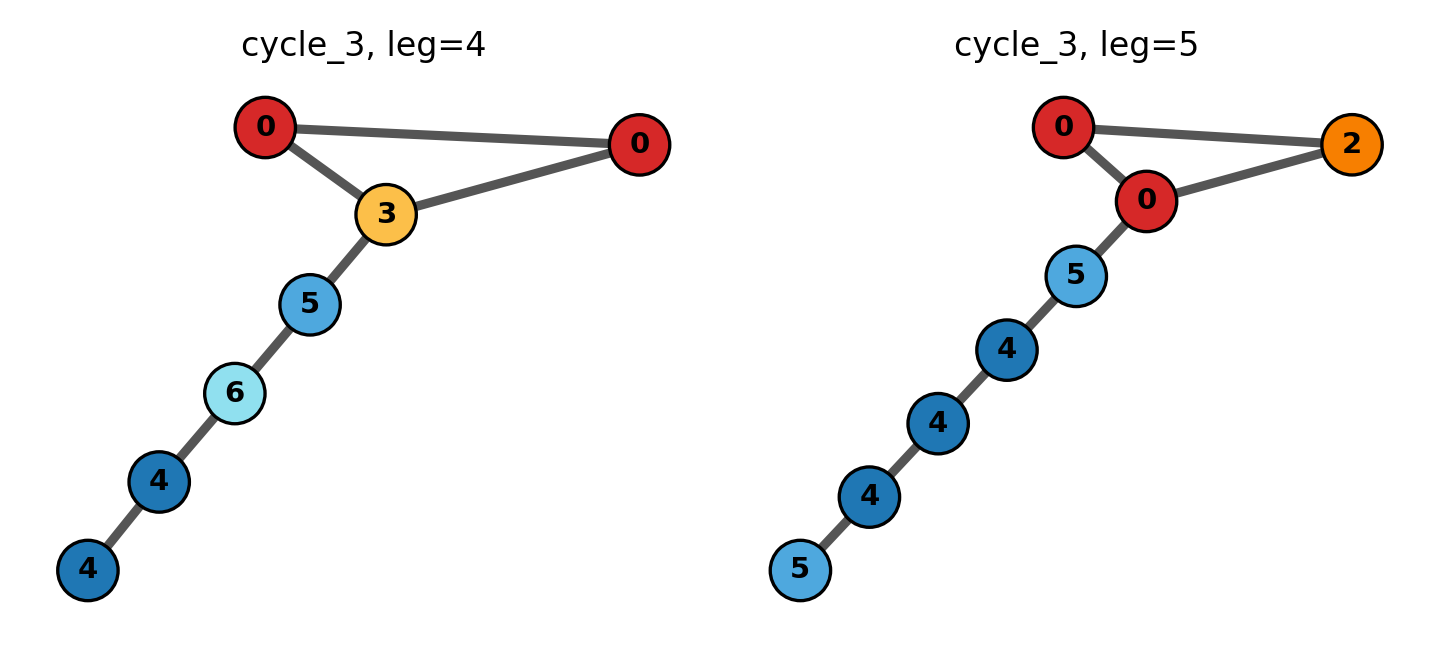

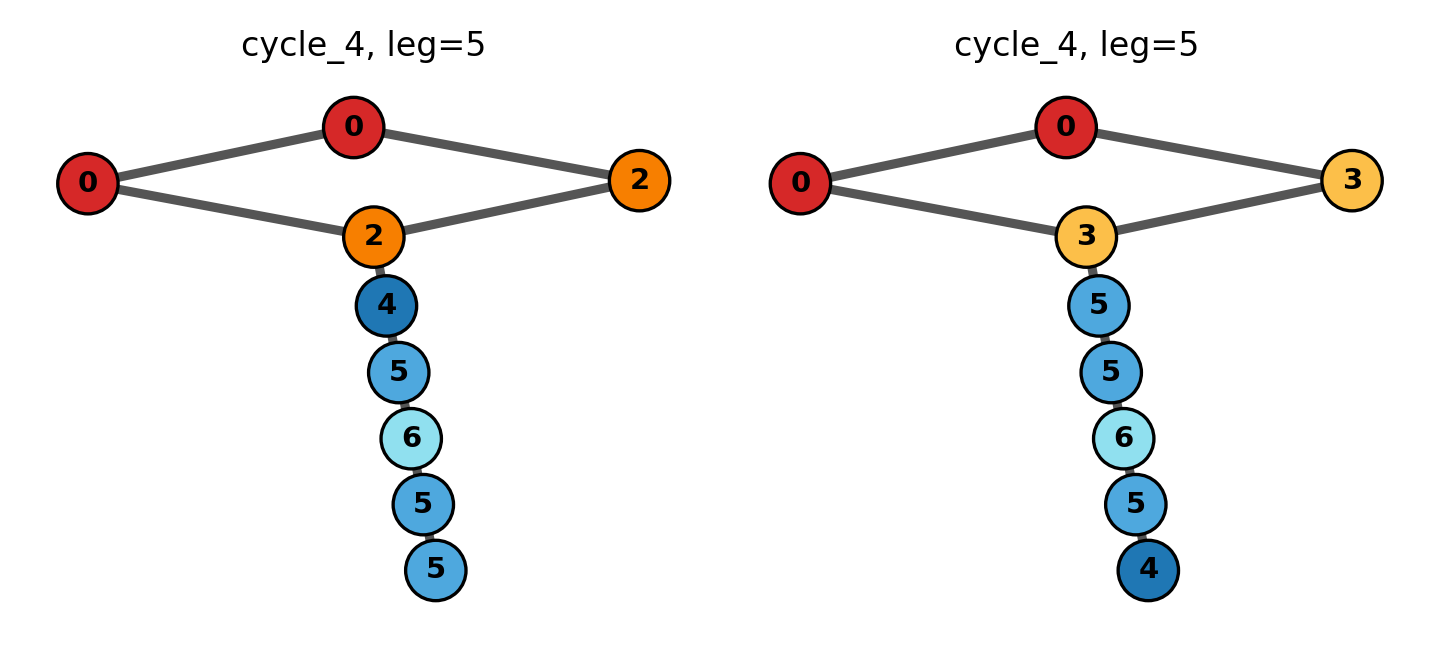

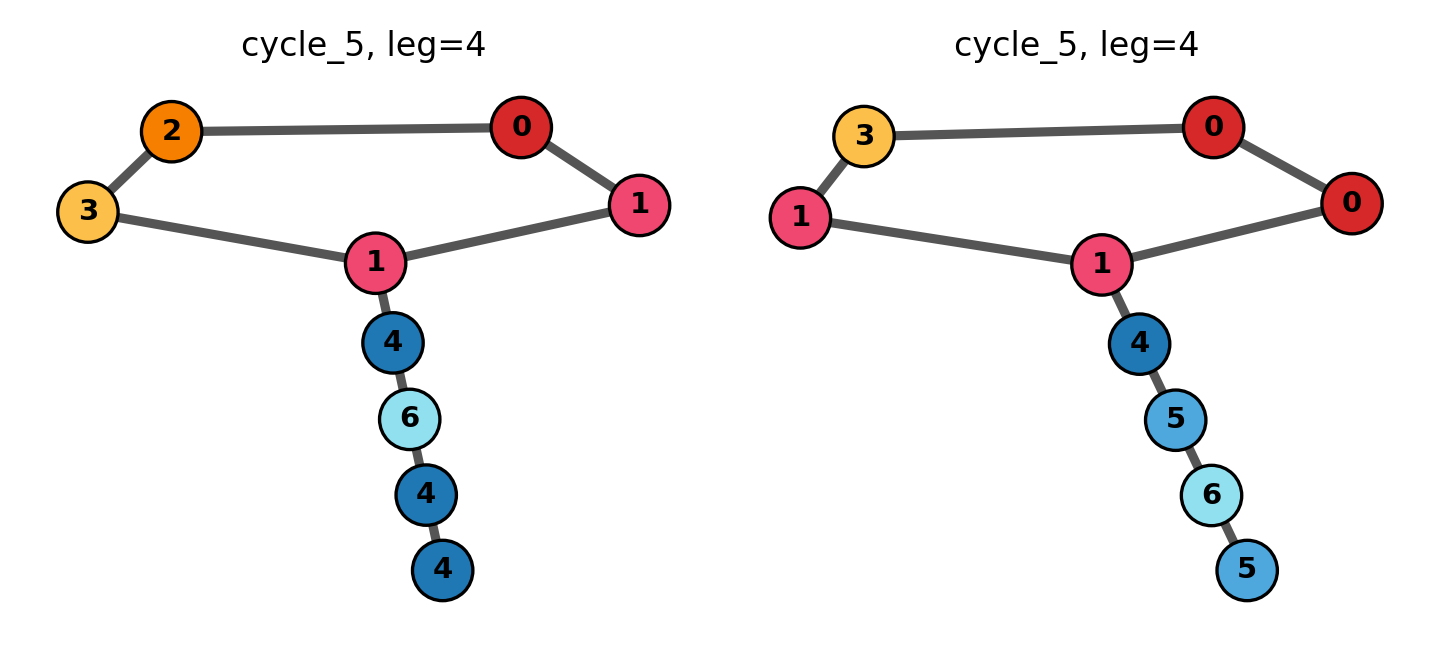

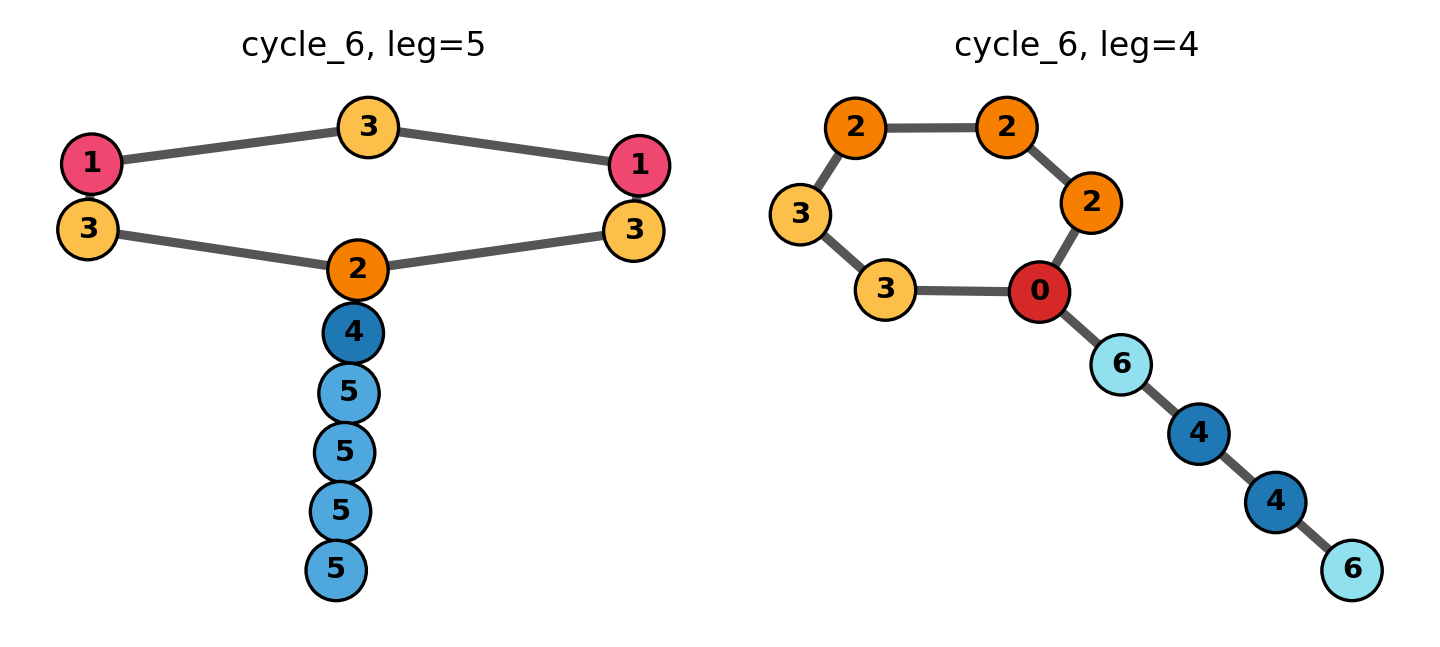

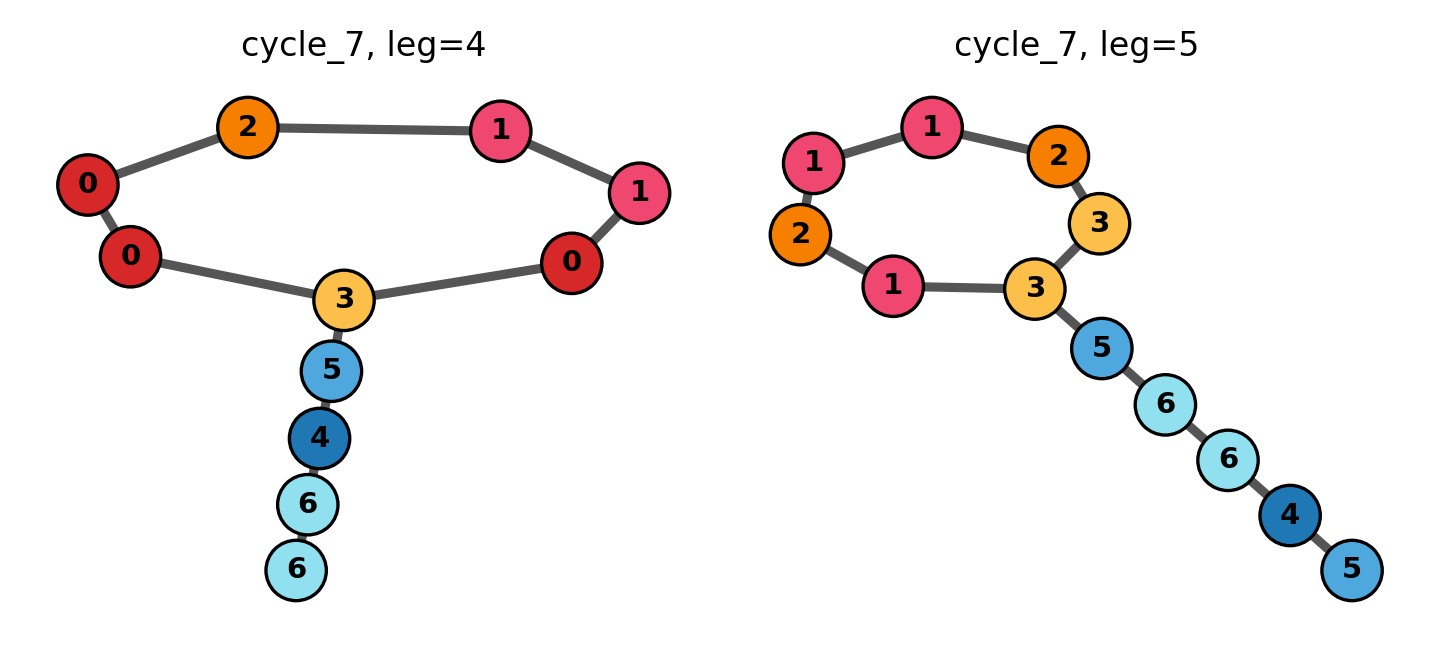

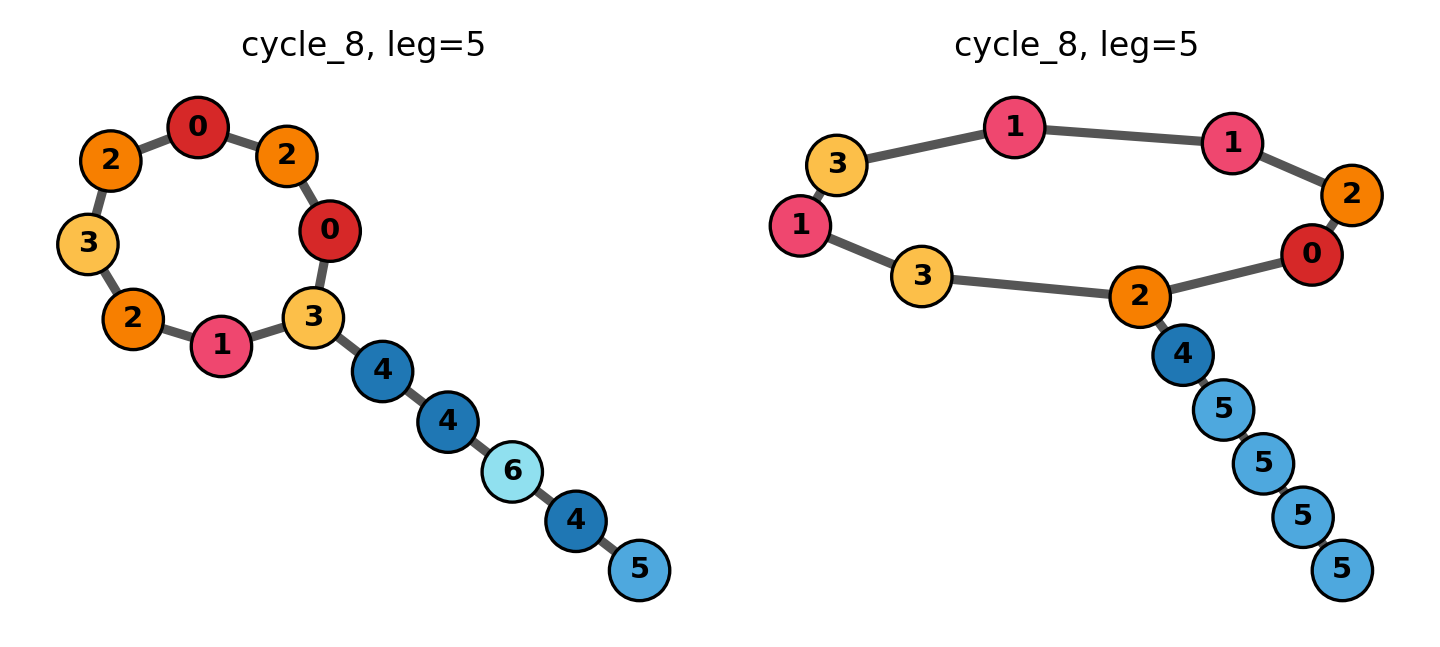

CPU times: user 3.22 s, sys: 1.71 s, total: 4.92 s
Wall time: 1.96 s


In [32]:
%%time
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================================
# Controlled supervisor experiment: cycle size with one leg
# ============================================================
# Four balanced categories:
#   cycle_3, cycle_4, cycle_5, cycle_6
# Each graph has one attached path containing 4 or 5 additional nodes.
# Per category: 750 training graphs + 100 test graphs.

CYCLE_SIZES = (3, 4, 5, 6,7,8)
LEG_SIZES = (4, 5)
TRAIN_GRAPHS_PER_CATEGORY = 3000
TEST_GRAPHS_PER_CATEGORY = 100
DATASET_SEED = 42
TARGET_ALPHABET_SIZE = 4
LEG_ALPHABET_SIZE = 3
MAX_UNIQUE_ATTEMPTS_PER_GRAPH = 20000

test_size = TEST_GRAPHS_PER_CATEGORY * len(CYCLE_SIZES)
dataset_size = (
    TRAIN_GRAPHS_PER_CATEGORY + TEST_GRAPHS_PER_CATEGORY
) * len(CYCLE_SIZES)
n_graphs_per_line = 8
ARTIFICIAL_VARIABLE_SIZE = True

GRAPH_TYPES = ["cycle_with_leg"]
INCLUDE_MOTIFS = {
    "target": True,
    "connector": True,
    "context": False,
}
UNIQUE_GRAPHS = True
RANDOMIZE_NODE_LABELS = True

MOTIF_CONFIG = {
    "target_type": "cycle",
    "connector_type": "path",
    "context_type": None,
    "target_size": CYCLE_SIZES,
    "connector_size": LEG_SIZES,
    "context_size": 0,
    "total_nodes": None,
}

ROLE_CONFIG = {
    "target": {
        "node_labels": list(range(TARGET_ALPHABET_SIZE)),
        "node_colors": ["#d62828", "#ef476f", "#f77f00", "#fcbf49"],
        "edge_labels": [0],
        "edge_colors": ["#d62828"],
    },
    "connector": {
        "node_labels": list(range(
            TARGET_ALPHABET_SIZE,
            TARGET_ALPHABET_SIZE + LEG_ALPHABET_SIZE,
        )),
        "node_colors": ["#1f77b4", "#4ea8de", "#90e0ef"],
        "edge_labels": [0],
        "edge_colors": ["#1f77b4"],
    },
    "context": {
        "node_labels": [],
        "node_colors": [],
        "edge_labels": [0],
        "edge_colors": ["#555555"],
    },
}

EDGE_CONFIG = {
    "set_edge_labels": False,
    "edge_alphabet": [0],
    "default_edge_label": 0,
    "edge_color_mode": "none",
}

MOTIF_LABELS = {
    role: list(spec["node_labels"])
    for role, spec in ROLE_CONFIG.items()
}
def _repeat_palette(colors, size):
    colors = list(colors) or ["#cccccc"]
    return [colors[index % len(colors)] for index in range(int(size))]


MOTIF_COLORS = {
    role: _repeat_palette(spec["node_colors"], len(spec["node_labels"]))
    for role, spec in ROLE_CONFIG.items()
}
NODE_ALPHABET = sorted(
    label
    for role in ("target", "connector")
    for label in MOTIF_LABELS[role]
)
alphabet_size = len(NODE_ALPHABET)
LABEL_TO_COLOR = {
    label: MOTIF_COLORS[role][index]
    for role in ("target", "connector")
    for index, label in enumerate(MOTIF_LABELS[role])
}
EDGE_LABEL_TO_COLOR = {0: "#555555"}


def make_cycle_leg_graph(cycle_size, leg_size, seed, graph_id, split):
    """Create one labeled cycle with one attached path leg."""
    cycle_size = int(cycle_size)
    leg_size = int(leg_size)
    if cycle_size < 3:
        raise ValueError("cycle_size must be at least 3")
    if leg_size < 1:
        raise ValueError("leg_size must be positive")

    rng = random.Random(int(seed))
    graph = nx.Graph()

    cycle_nodes = list(range(cycle_size))
    leg_nodes = list(range(cycle_size, cycle_size + leg_size))

    for index, node in enumerate(cycle_nodes):
        label = rng.choice(MOTIF_LABELS["target"])
        graph.add_node(
            node,
            label=label,
            attr=label,
            plot_label=label,
            display_label=label,
            plot_color=LABEL_TO_COLOR[label],
            motif="target",
            motif_role="target",
            motif_type="cycle",
            node_role="cycle",
            cycle_position=index,
        )

    for index, node in enumerate(leg_nodes):
        label = rng.choice(MOTIF_LABELS["connector"])
        graph.add_node(
            node,
            label=label,
            attr=label,
            plot_label=label,
            display_label=label,
            plot_color=LABEL_TO_COLOR[label],
            motif="connector",
            motif_role="connector",
            motif_type="path",
            node_role="leg",
            leg_position=index,
        )

    for index, node in enumerate(cycle_nodes):
        graph.add_edge(
            node,
            cycle_nodes[(index + 1) % cycle_size],
            label=0,
            edge_attr=0,
            plot_label=0,
            plot_color="#555555",
            motif="target",
            motif_role="target",
            motif_type="cycle",
        )

    # Random attachment position prevents node index from identifying the category.
    attachment_node = rng.choice(cycle_nodes)
    graph.add_edge(
        attachment_node,
        leg_nodes[0],
        label=0,
        edge_attr=0,
        plot_label=0,
        plot_color="#555555",
        motif="connector",
        motif_role="connector",
        motif_type="path",
    )
    for left, right in zip(leg_nodes[:-1], leg_nodes[1:]):
        graph.add_edge(
            left,
            right,
            label=0,
            edge_attr=0,
            plot_label=0,
            plot_color="#555555",
            motif="connector",
            motif_role="connector",
            motif_type="path",
        )

    graph.graph.update(
        {
            "graph_id": int(graph_id),
            "split": str(split),
            "category": f"cycle_{cycle_size}",
            "motif_family": "cycle_with_leg",
            "target_type": "cycle",
            "connector_type": "path",
            "context_type": None,
            "target_size": cycle_size,
            "cycle_size": cycle_size,
            "connector_size": leg_size,
            "leg_size": leg_size,
            "context_size": 0,
            "branch_count": 1,
            "branch_lengths": (leg_size,),
            "total_nodes": cycle_size + leg_size,
            "attachment_node": attachment_node,
        }
    )
    return graph


def labeled_cycle_leg_signature(graph):
    """Canonical label signature, invariant to reflecting the rooted cycle."""
    cycle_size = int(graph.graph["cycle_size"])
    leg_size = int(graph.graph["leg_size"])
    attachment = int(graph.graph["attachment_node"])

    forward_cycle = tuple(
        int(graph.nodes[(attachment + offset) % cycle_size]["label"])
        for offset in range(cycle_size)
    )
    reverse_cycle = tuple(
        int(graph.nodes[(attachment - offset) % cycle_size]["label"])
        for offset in range(cycle_size)
    )
    canonical_cycle = min(forward_cycle, reverse_cycle)
    leg_labels = tuple(
        int(graph.nodes[cycle_size + offset]["label"])
        for offset in range(leg_size)
    )
    return cycle_size, leg_size, canonical_cycle, leg_labels


def build_balanced_cycle_leg_split(
    per_category,
    split,
    seed,
    used_signatures=None,
):
    """Build a balanced split with no repeated labeled motif signatures."""
    graphs = []
    targets = []
    rng = random.Random(int(seed))
    graph_id = 0
    used_signatures = set() if used_signatures is None else used_signatures
    split_signatures = set()

    for cycle_size in CYCLE_SIZES:
        leg_schedule = [
            LEG_SIZES[index % len(LEG_SIZES)]
            for index in range(int(per_category))
        ]
        rng.shuffle(leg_schedule)

        category_graphs = []
        for leg_size in leg_schedule:
            graph = None
            signature = None
            for _ in range(MAX_UNIQUE_ATTEMPTS_PER_GRAPH):
                graph_seed = rng.randint(0, 2**31 - 1)
                candidate = make_cycle_leg_graph(
                    cycle_size=cycle_size,
                    leg_size=leg_size,
                    seed=graph_seed,
                    graph_id=graph_id,
                    split=split,
                )
                candidate_signature = labeled_cycle_leg_signature(candidate)
                if candidate_signature not in used_signatures:
                    graph = candidate
                    signature = candidate_signature
                    break
            if graph is None:
                raise RuntimeError(
                    "Could not create enough unique labeled graphs for "
                    f"cycle={cycle_size}, leg={leg_size}. Increase the target/leg "
                    "alphabet sizes or reduce the requested graph count."
                )
            used_signatures.add(signature)
            split_signatures.add(signature)
            graph.graph["labeled_signature"] = signature
            category_graphs.append((graph, f"cycle_{cycle_size}"))
            graph_id += 1

        rng.shuffle(category_graphs)
        graphs.extend(graph for graph, _ in category_graphs)
        targets.extend(target for _, target in category_graphs)

    paired = list(zip(graphs, targets))
    rng.shuffle(paired)
    return (
        [graph for graph, _ in paired],
        [target for _, target in paired],
        split_signatures,
    )


def ensure_plot_attrs(graphs):
    for graph in graphs:
        for _, data in graph.nodes(data=True):
            label = int(data.get("label", 0))
            data["label"] = label
            data["attr"] = label
            data["plot_label"] = label
            data["display_label"] = label
            data["plot_color"] = LABEL_TO_COLOR.get(label, "#cccccc")
        for _, _, data in graph.edges(data=True):
            data["label"] = 0
            data["edge_attr"] = 0
            data["plot_label"] = 0
            data["plot_color"] = "#555555"


def plot_motif_graphs(graphs, n_cols=8, node_size=210, edge_width=2.2):
    if not graphs:
        return
    n_rows = math.ceil(len(graphs) / n_cols)
    figure, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.45 * n_cols, 2.25 * n_rows),
        dpi=150,
    )
    axes = np.asarray(axes).reshape(-1)

    for axis, graph in zip(axes, graphs):
        try:
            positions = nx.kamada_kawai_layout(graph)
        except Exception:
            positions = nx.spring_layout(graph, seed=42)
        nx.draw_networkx_edges(
            graph,
            positions,
            ax=axis,
            edge_color=[
                graph.edges[u, v].get("plot_color", "#555555")
                for u, v in graph.edges()
            ],
            width=edge_width,
        )
        nx.draw_networkx_nodes(
            graph,
            positions,
            ax=axis,
            node_color=[
                graph.nodes[node].get("plot_color", "#cccccc")
                for node in graph.nodes()
            ],
            edgecolors="black",
            linewidths=0.8,
            node_size=node_size,
        )
        nx.draw_networkx_labels(
            graph,
            positions,
            ax=axis,
            labels={
                node: graph.nodes[node].get("plot_label", "")
                for node in graph.nodes()
            },
            font_size=7,
            font_weight="bold",
        )
        axis.set_title(
            f"{graph.graph['category']}, leg={graph.graph['leg_size']}",
            fontsize=8,
        )
        axis.axis("off")

    for axis in axes[len(graphs):]:
        axis.axis("off")
    plt.tight_layout()
    plt.show()


all_labeled_signatures = set()
train_graphs, train_targets, train_labeled_signatures = build_balanced_cycle_leg_split(
    per_category=TRAIN_GRAPHS_PER_CATEGORY,
    split="train",
    seed=DATASET_SEED,
    used_signatures=all_labeled_signatures,
)
test_graphs, test_targets, test_labeled_signatures = build_balanced_cycle_leg_split(
    per_category=TEST_GRAPHS_PER_CATEGORY,
    split="test",
    seed=DATASET_SEED + 1,
    used_signatures=all_labeled_signatures,
)
ensure_plot_attrs(train_graphs)
ensure_plot_attrs(test_graphs)

# Compatibility variables expected by later notebook cells.
graphs = list(train_graphs) + list(test_graphs)
targets = list(train_targets) + list(test_targets)
original_graphs = np.asarray(graphs, dtype=object)
original_targets = np.asarray(targets, dtype=object)

print("controlled artificial cycle-with-leg dataset")
print("cycle sizes:", CYCLE_SIZES)
print("leg sizes (additional path nodes):", LEG_SIZES)
print("target/leg alphabet sizes:", TARGET_ALPHABET_SIZE, LEG_ALPHABET_SIZE)
print("label-aware uniqueness enabled:", UNIQUE_GRAPHS)
print("train/test:", len(train_graphs), len(test_graphs))
print("train category counts:", Counter(train_targets))
print("test category counts :", Counter(test_targets))
print(
    "train cycle/leg counts:",
    Counter(
        (graph.graph["cycle_size"], graph.graph["leg_size"])
        for graph in train_graphs
    ),
)
print(
    "test cycle/leg counts :",
    Counter(
        (graph.graph["cycle_size"], graph.graph["leg_size"])
        for graph in test_graphs
    ),
)
print(
    "total-node counts:",
    Counter(graph.number_of_nodes() for graph in graphs),
)
print("unique train labeled signatures:", len(train_labeled_signatures))
print("unique test labeled signatures :", len(test_labeled_signatures))
print(
    "train/test labeled-signature overlap:",
    len(train_labeled_signatures & test_labeled_signatures),
)

expected_train_counts = {
    f"cycle_{cycle_size}": TRAIN_GRAPHS_PER_CATEGORY
    for cycle_size in CYCLE_SIZES
}
expected_test_counts = {
    f"cycle_{cycle_size}": TEST_GRAPHS_PER_CATEGORY
    for cycle_size in CYCLE_SIZES
}
expected_train_leg_count = TRAIN_GRAPHS_PER_CATEGORY // len(LEG_SIZES)
expected_test_leg_count = TEST_GRAPHS_PER_CATEGORY // len(LEG_SIZES)

if Counter(train_targets) != Counter(expected_train_counts):
    raise RuntimeError("Training categories are not balanced as configured.")
if Counter(test_targets) != Counter(expected_test_counts):
    raise RuntimeError("Test categories are not balanced as configured.")
for cycle_size in CYCLE_SIZES:
    for leg_size in LEG_SIZES:
        train_count = sum(
            graph.graph["cycle_size"] == cycle_size
            and graph.graph["leg_size"] == leg_size
            for graph in train_graphs
        )
        test_count = sum(
            graph.graph["cycle_size"] == cycle_size
            and graph.graph["leg_size"] == leg_size
            for graph in test_graphs
        )
        if train_count != expected_train_leg_count:
            raise RuntimeError(
                f"Unexpected training count for cycle={cycle_size}, leg={leg_size}: "
                f"{train_count}."
            )
        if test_count != expected_test_leg_count:
            raise RuntimeError(
                f"Unexpected test count for cycle={cycle_size}, leg={leg_size}: "
                f"{test_count}."
            )
if len(train_labeled_signatures) != len(train_graphs):
    raise RuntimeError("Duplicate labeled graph signatures found in training.")
if len(test_labeled_signatures) != len(test_graphs):
    raise RuntimeError("Duplicate labeled graph signatures found in test.")
if train_labeled_signatures & test_labeled_signatures:
    raise RuntimeError("Training and test labeled graph signatures overlap.")

print("Dataset validation passed: balanced, unique, and train/test-disjoint.")

for cycle_size in CYCLE_SIZES:
    examples = [
        graph
        for graph in test_graphs
        if graph.graph["cycle_size"] == cycle_size
    ][:2]
    plot_motif_graphs(examples, n_cols=2)


In [33]:
from collections import Counter
import networkx as nx
import matplotlib.pyplot as plt

def plot_label_comparative_histogram(
    probe_train_graphs,
    decoded_graphs,
    conditioning_decoded_graphs,
    labels=('Probe Train Graphs', 'Decoded Graphs', 'Conditioning Decoded Graphs'),
    title='Comparative Histogram of Node Labels Across Graph Sets',
    figsize=(12, 6),
    bar_edgecolor='black',
    annotate=True,
    annotate_offset=3  # points above the bar
):
    """
    Plots a grouped bar chart comparing node 'label' attribute frequencies
    across three lists of networkx graphs.
    """

    def _norm_label(x):
        # Make everything a stable, comparable string key
        try:
            hash(x)            # ensure hashable; if not, fall back to repr
        except TypeError:
            x = repr(x)
        return str(x)

    def _get_label_counts(graph_list):
        counts = Counter()
        for G in graph_list:
            for v in nx.get_node_attributes(G, 'label').values():
                counts[_norm_label(v)] += 1
        return counts

    # Compute normalized label counts
    counts_list = [
        _get_label_counts(probe_train_graphs),
        _get_label_counts(decoded_graphs),
        _get_label_counts(conditioning_decoded_graphs)
    ]

    # Union of all stringified labels, sorted lexicographically
    all_labels = sorted(set().union(*[c.keys() for c in counts_list]))
    x = range(len(all_labels))
    width = 0.25

    # Align counts to all_labels order
    vals = [[c.get(lbl, 0) for lbl in all_labels] for c in counts_list]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    bars1 = ax.bar([i - width for i in x], vals[0], width=width,
                   label=labels[0], edgecolor=bar_edgecolor)
    bars2 = ax.bar(x,               vals[1], width=width,
                   label=labels[1], edgecolor=bar_edgecolor)
    bars3 = ax.bar([i + width for i in x], vals[2], width=width,
                   label=labels[2], edgecolor=bar_edgecolor)

    # Annotate counts
    if annotate:
        for bar in list(bars1) + list(bars2) + list(bars3):
            height = bar.get_height()
            ax.annotate(
                f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, annotate_offset),
                textcoords="offset points",
                ha='center',
                va='bottom'
            )

    ax.set_xticks(list(x))
    ax.set_xticklabels(all_labels, rotation=0, ha='right')
    ax.set_xlabel('Node Label')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

# === WL & NSPDK MMD from NetworkX graphs (one cell) ==========================
import numpy as np, networkx as nx

def _to_simple_undirected(G):
    H = nx.Graph(G) if isinstance(G, (nx.DiGraph, nx.MultiDiGraph)) else G.copy()
    H.remove_edges_from(nx.selfloop_edges(H))
    return H

def _nonempty(graphs):
    return [G for G in graphs if _to_simple_undirected(G).number_of_nodes() > 0]

# ---------------- GraKeL conversion: build Graph objects ---------------------
def nx_to_grakel_wl(graphs, node_label_key="label"):
    """For WL+VertexHistogram: Graph(adjacency, node_labels, None)."""
    from grakel import Graph
    glist = []
    for G in _nonempty(graphs):
        H = _to_simple_undirected(G)
        nodes = list(H.nodes())
        n = len(nodes)
        idx = {u: i for i, u in enumerate(nodes)}
        A = np.zeros((n, n), dtype=int)
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            A[i, j] = 1; A[j, i] = 1
        # node labels: use provided key if present, else a constant label "0"
        if all(node_label_key in H.nodes[u] for u in nodes):
            vlab = {idx[u]: str(H.nodes[u][node_label_key]) for u in nodes}
        else:
            vlab = {i: "0" for i in range(n)}
        glist.append(Graph(A, vlab, None))  # <-- removed directed kwarg
    return glist

def nx_to_grakel_nspdk(graphs, node_label_key="label"):
    """For NSPDK: Graph(adjacency, node_labels, edge_labels). Edge labels set to '1'."""
    from grakel import Graph
    glist = []
    for G in _nonempty(graphs):
        H = _to_simple_undirected(G)
        nodes = list(H.nodes())
        n = len(nodes)
        idx = {u: i for i, u in enumerate(nodes)}
        A = np.zeros((n, n), dtype=int)
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            A[i, j] = 1; A[j, i] = 1
        # node labels: provided if present, else "0"
        if all(node_label_key in H.nodes[u] for u in nodes):
            vlab = {idx[u]: str(H.nodes[u][node_label_key]) for u in nodes}
        else:
            vlab = {i: "0" for i in range(n)}
        # edge labels: constant '1' on existing edges (both directions)
        elab = {}
        for u, v in H.edges():
            i, j = idx[u], idx[v]
            elab[(i, j)] = '1'
            elab[(j, i)] = '1'
        glist.append(Graph(A, vlab, elab))  # <-- removed directed kwarg
    return glist

# ---------------- MMD utilities ----------------------------------------------
def _mmd2_unbiased(Kxx, Kyy, Kxy):
    m, n = Kxx.shape[0], Kyy.shape[0]
    if m < 2 or n < 2: return np.nan, np.nan
    Kxx = Kxx.copy(); Kyy = Kyy.copy()
    np.fill_diagonal(Kxx, 0.0); np.fill_diagonal(Kyy, 0.0)
    term_x = Kxx.sum()/(m*(m-1))
    term_y = Kyy.sum()/(n*(n-1))
    term_xy = 2.0*Kxy.sum()/(m*n)
    mmd2 = term_x + term_y - term_xy
    return float(mmd2), float(np.sqrt(max(mmd2, 0.0)))

# ---------------- WL (VertexHistogram) MMD -----------------------------------
def wl_mmd(true_graphs, gen_graphs, node_label_key="label", n_iter=5, normalize=True):
    try:
        from grakel.kernels import WeisfeilerLehman, VertexHistogram
    except Exception as e:
        raise RuntimeError("GraKeL not installed. pip install grakel") from e
    Gx = nx_to_grakel_wl(true_graphs, node_label_key)
    Gy = nx_to_grakel_wl(gen_graphs,  node_label_key)
    if len(Gx) == 0 or len(Gy) == 0:
        return {"wl_mmd": np.nan, "wl_mmd2": np.nan, "note": "empty after parsing"}
    base_spec = (VertexHistogram, {"normalize": normalize})
    wl_x = WeisfeilerLehman(n_iter=n_iter, base_graph_kernel=base_spec, normalize=normalize)
    Kxx = wl_x.fit_transform(Gx)
    Kxy = wl_x.transform(Gy)
    wl_y = WeisfeilerLehman(n_iter=n_iter, base_graph_kernel=base_spec, normalize=normalize)
    Kyy = wl_y.fit_transform(Gy)
    mmd2, mmd = _mmd2_unbiased(Kxx, Kyy, Kxy)
    return {"wl_mmd": mmd, "wl_mmd2": mmd2, "wl_n_iter": n_iter}

# ---------------- NSPDK MMD ---------------------------------------------------
def nspdk_mmd(true_graphs, gen_graphs, node_label_key="label", r=1, d=6, normalize=True, n_jobs=-1):
    try:
        from grakel.kernels import NeighborhoodSubgraphPairwiseDistance as NSPDK
    except Exception as e:
        raise RuntimeError("GraKeL not installed. pip install grakel") from e
    Gx = nx_to_grakel_nspdk(true_graphs, node_label_key)
    Gy = nx_to_grakel_nspdk(gen_graphs,  node_label_key)
    if len(Gx) == 0 or len(Gy) == 0:
        return {"nspdk_mmd": np.nan, "nspdk_mmd2": np.nan, "note": "empty after parsing"}
    K = NSPDK(r=r, d=d, normalize=normalize, n_jobs=n_jobs)
    Kxx = K.fit_transform(Gx)
    Kxy = K.transform(Gy)
    Ky = NSPDK(r=r, d=d, normalize=normalize, n_jobs=n_jobs)
    Kyy = Ky.fit_transform(Gy)
    mmd2, mmd = _mmd2_unbiased(Kxx, Kyy, Kxy)
    return {"nspdk_mmd": mmd, "nspdk_mmd2": mmd2, "nspdk_r": r, "nspdk_d": d}

# # ---------------- Example run on your three sets ------------------------------
# # Assumes you already have: probe_train_graphs, decoded_graphs, conditioning_decoded_graphs
# wl_true_vs_nodes = wl_mmd(probe_train_graphs, decoded_graphs, n_iter=5, normalize=True)
# wl_true_vs_cond  = wl_mmd(probe_train_graphs, conditioning_decoded_graphs, n_iter=5, normalize=True)
# ns_true_vs_nodes = nspdk_mmd(probe_train_graphs, decoded_graphs, r=1, d=4, normalize=True)
# ns_true_vs_cond  = nspdk_mmd(probe_train_graphs, conditioning_decoded_graphs, r=1, d=4, normalize=True)

# print("WL  (true vs nodes):", wl_true_vs_nodes)
# print("WL  (true vs cond) :", wl_true_vs_cond)
# print("NSPDK (true vs nodes):", ns_true_vs_nodes)
# print("NSPDK (true vs cond) :", ns_true_vs_cond)


In [34]:
# ===== Optional split train into train1/train2, keep existing test split =====

from collections import Counter
from sklearn.model_selection import train_test_split

DO_TRAIN_SPLIT = True
USE_TRAIN1_FOR_DOWNSTREAM = False

if DO_TRAIN_SPLIT:

    def _ensure_nsppk_labels(graphs, default_node_label=0, default_edge_label=0):
        out = []
        d = int(default_node_label)
        de = int(default_edge_label)

        for g in graphs:
            h = g.copy()

            for u in h.nodes():
                attrs = h.nodes[u]
                raw = attrs.get('label', attrs.get('display_label', attrs.get('true_label', d)))
                try:
                    lbl = int(raw)
                except Exception:
                    lbl = d

                attrs['label'] = lbl
                attrs['display_label'] = int(attrs.get('display_label', lbl)) if str(attrs.get('display_label', lbl)).lstrip('-').isdigit() else lbl
                attrs['true_label'] = int(attrs.get('true_label', lbl)) if str(attrs.get('true_label', lbl)).lstrip('-').isdigit() else lbl

            for u, v in h.edges():
                eattrs = h.edges[u, v]
                eraw = eattrs.get('label', eattrs.get('true_label', de))
                try:
                    elbl = int(eraw)
                except Exception:
                    elbl = de

                eattrs['label'] = elbl
                eattrs['true_label'] = int(eattrs.get('true_label', elbl)) if str(eattrs.get('true_label', elbl)).lstrip('-').isdigit() else elbl

            out.append(h)

        return out


    train_graphs = _ensure_nsppk_labels(train_graphs)
    test_graphs = _ensure_nsppk_labels(test_graphs)

    train_whole_graphs = [g.copy() for g in train_graphs]
    train_whole_targets = None if train_targets is None else list(train_targets)

    if train_whole_targets is None:
        train1_graphs, train2_graphs = train_test_split(
            train_whole_graphs,
            test_size=0.5,
            random_state=42,
        )
        train1_targets = None
        train2_targets = None
    else:
        counts = Counter(train_whole_targets)
        can_stratify = len(counts) > 1 and min(counts.values()) >= 2
        stratify_arg = train_whole_targets if can_stratify else None

        train1_graphs, train2_graphs, train1_targets, train2_targets = train_test_split(
            train_whole_graphs,
            train_whole_targets,
            test_size=0.5,
            random_state=42,
            stratify=stratify_arg,
        )

    if USE_TRAIN1_FOR_DOWNSTREAM:
        train_graphs = train1_graphs
        train_targets = train1_targets
        print('downstream training source: train1')
    else:
        train_graphs = train_whole_graphs
        train_targets = train_whole_targets
        print('downstream training source: train_whole')

    print('train_whole/train1/train2/test:', len(train_whole_graphs), len(train1_graphs), len(train2_graphs), len(test_graphs))
    if train_whole_targets is None:
        print('train_whole class counts: unlabeled')
        print('train1 class counts     : unlabeled')
        print('train2 class counts     : unlabeled')
        print('test class counts       : unlabeled')
    else:
        print('train_whole class counts:', Counter(train_whole_targets))
        print('train1 class counts     :', Counter(train1_targets))
        print('train2 class counts     :', Counter(train2_targets))
        print('test class counts       :', Counter(test_targets))


    # ===== Debug classifier: NSPPK on train1/train2/train1+train2 =====

    import numpy as np
    from sklearn.ensemble import ExtraTreesClassifier
    from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
    from coco_grape.graph_vectorizer.nsppk import NSPPK


    def _safe_f1(y_true, y_pred):
        labels = sorted(set(y_true) | set(y_pred))
        if len(labels) <= 2:
            return float(f1_score(y_true, y_pred, zero_division=0))
        return float(f1_score(y_true, y_pred, average='macro', zero_division=0))


    def _evaluate_split_repeated(graphs, targets, label, n_repeats=10, base_seed=42):
        if not graphs:
            print(f'{label}: no graphs to evaluate')
            return

        targets = list(targets)
        counts = Counter(targets)
        if len(graphs) < 5 or len(counts) < 2 or min(counts.values()) < 2:
            print(f'{label}: skipped repeated eval, too few examples/classes: {counts}')
            return

        f1_vals = []
        bal_vals = []
        acc_vals = []

        for rep in range(int(n_repeats)):
            seed = int(base_seed) + rep
            idx = np.arange(len(graphs))

            tr_idx, va_idx = train_test_split(
                idx,
                test_size=0.2,
                random_state=seed,
                stratify=targets,
            )

            g_tr = [graphs[i] for i in tr_idx]
            g_va = [graphs[i] for i in va_idx]
            y_tr = [targets[i] for i in tr_idx]
            y_va = [targets[i] for i in va_idx]

            vec = NSPPK(radius=1, distance=4, connector=0, nbits=12, dense=False, parallel=False)
            X_tr = vec.fit_transform(g_tr, y_tr)
            X_va = vec.transform(g_va)

            clf = ExtraTreesClassifier(n_estimators=300, random_state=seed, n_jobs=-1)
            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_va)

            f1_vals.append(_safe_f1(y_va, preds))
            bal_vals.append(float(balanced_accuracy_score(y_va, preds)))
            acc_vals.append(float(accuracy_score(y_va, preds)))

        print(
            f"{label} summary: "
            f"f1={np.mean(f1_vals):.3f}+-{np.std(f1_vals):.3f} "
            f"bal={np.mean(bal_vals):.3f}+-{np.std(bal_vals):.3f} "
            f"acc={np.mean(acc_vals):.3f}+-{np.std(acc_vals):.3f}"
        )


    N_REPEATS = 1
    BASE_SEED = int(globals().get('SEED', 42))

    if train_whole_targets is None:
        print('NSPPK split classifier skipped: graph targets are unlabeled')
    else:
        _evaluate_split_repeated(train1_graphs, train1_targets, 'train1', n_repeats=N_REPEATS, base_seed=BASE_SEED)
        _evaluate_split_repeated(train2_graphs, train2_targets, 'train2', n_repeats=N_REPEATS, base_seed=BASE_SEED)

        combined_graphs = train1_graphs + train2_graphs
        combined_targets = list(train1_targets) + list(train2_targets)
        _evaluate_split_repeated(combined_graphs, combined_targets, 'train1+train2', n_repeats=N_REPEATS, base_seed=BASE_SEED)


downstream training source: train_whole
train_whole/train1/train2/test: 18000 9000 9000 600
train_whole class counts: Counter({'cycle_5': 3000, 'cycle_7': 3000, 'cycle_8': 3000, 'cycle_3': 3000, 'cycle_4': 3000, 'cycle_6': 3000})
train1 class counts     : Counter({'cycle_7': 1500, 'cycle_8': 1500, 'cycle_3': 1500, 'cycle_6': 1500, 'cycle_5': 1500, 'cycle_4': 1500})
train2 class counts     : Counter({'cycle_5': 1500, 'cycle_8': 1500, 'cycle_7': 1500, 'cycle_3': 1500, 'cycle_4': 1500, 'cycle_6': 1500})
test class counts       : Counter({'cycle_7': 100, 'cycle_3': 100, 'cycle_8': 100, 'cycle_6': 100, 'cycle_4': 100, 'cycle_5': 100})
train1 summary: f1=0.968+-0.000 bal=0.968+-0.000 acc=0.968+-0.000
train2 summary: f1=0.970+-0.000 bal=0.971+-0.000 acc=0.971+-0.000
train1+train2 summary: f1=0.983+-0.000 bal=0.983+-0.000 acc=0.983+-0.000


In [35]:
nbits = 13
verbose = True

In [36]:
import numpy as np
from scipy import sparse
import torch
from torch_geometric.loader import DataLoader

from coco_grape.module.quotientgraph.display import (
    display,
    display_mappings,
    display_decomposition_graph,
    decomposition_to_graph,
)
from coco_grape.module.quotientgraph.vectorize import (
    QuotientGraphTransformer,
    QuotientGraphNodeTransformer,
)
from coco_grape.module.quotientgraph.operator import *

from coco_grape.data_processor.generative.nn_embedding_vectorizer import (
    NnGraphVectorizer,
    NnVectorizerConfig,
    get_pyg_graphs_from_nx,
)

from coco_grape.graph_vectorizer.nsppk import NSPPK, NodeNSPPK


# ============================================================
# Choose vectorizers here
# ============================================================
NODE_VECTORIZER_MODE = "quotient"   # "quotient", "nsppk", "graphcl", "infograph", "gin-random"
GRAPH_VECTORIZER_MODE = "quotient"  # "quotient", "nsppk", "graphcl", "infograph", "gin-random"

NN_EMBED_MODE = "train"
NN_HIDDEN_DIM = 128
NN_NUM_LAYERS = 5
NN_EPOCHS = 1000
NN_BATCH_SIZE = 64
NN_LR = 1e-3
NN_DEVICE = "cpu"

nbits = 14

NSPPK_PARAMS = dict(
    radius=1,
    distance=4,
    connector=1,
    nbits=nbits,
    dense=True,
    parallel=True,
    use_edges_as_features=True,
)


# ============================================================
# Shared helpers
# ============================================================
def make_safe_graph_labels(graphs, default_node_label=0, default_edge_label=0):
    out = []

    for G in graphs:
        H = G.copy()

        for u, data in H.nodes(data=True):
            raw = data.get("label", data.get("plot_label", data.get("display_label", default_node_label)))
            try:
                label = int(round(float(raw)))
            except Exception:
                label = int(default_node_label)

            data["label"] = label
            data["attr"] = label
            data["display_label"] = label

        for u, v, data in H.edges(data=True):
            raw = data.get("label", data.get("plot_label", default_edge_label))
            try:
                label = int(round(float(raw)))
            except Exception:
                label = int(default_edge_label)

            data["label"] = label
            data["edge_attr"] = label

        out.append(H)

    return out


def make_quotient_df():
    df0_list = [
        compose(combination(distance=(d, d)), node(), prepend_label(label=d))
        for d in range(2, 10)
    ]
    df0 = add(*df0_list)

    df1 = add(
        df0,
        cycle(),
        tree(),
        path(number_of_edges=(1, 3)),
        neighborhood(radius=(0, 2)),
    )

    df2 = compose(df1, unlabel())
    return add(df1, df2)


def draw(graph, df, nbits):
    display_decomposition_graph(decomposition_to_graph(df))
    qg = QuotientGraph(graph=graph).create_default_image_node().update()
    qg = df(qg)
    qg.update()
    display(qg)
    display_mappings(qg)


# ============================================================
# Learned graph-level C vectorizer
# ============================================================
class DenseNnGraphVectorizer:
    def __init__(
        self,
        feature_extractor="graphcl",
        dataset_name="my_dataset",
        mode="train",
        fit_targets=None,
        hidden_dim=128,
        num_layers=4,
        epochs=300,
        batch_size=64,
        lr=1e-3,
        device="cpu",
    ):
        self.feature_extractor = feature_extractor
        self.dataset_name = dataset_name
        self.mode = mode
        self.fit_targets = fit_targets
        self.is_fitted_ = False

        self.config = NnVectorizerConfig(
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            device=device,
            allow_random_fallback=True,
        )

        self.vec = NnGraphVectorizer(
            feature_extractor=feature_extractor,
            dataset_name=dataset_name,
            mode=mode,
            config=self.config,
        )

    def fit(self, graphs, y=None):
        if self.is_fitted_ and y is None:
            return self

        targets = y
        if targets is None and self.fit_targets is not None and len(self.fit_targets) == len(graphs):
            targets = self.fit_targets

        graphs = make_safe_graph_labels(graphs)
        self.vec.fit(graphs, targets=targets)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        graphs = make_safe_graph_labels(graphs)
        X = self.vec.transform(graphs)

        if isinstance(X, tuple):
            X = X[0]

        if sparse.issparse(X):
            X = X.toarray()

        return np.asarray(X, dtype=float)

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# Learned node-level X vectorizer
# ============================================================
class LearnedGNNNodeVectorizer:
    def __init__(self, graph_vectorizer_ref, batch_size=64, device="cpu"):
        self.graph_vectorizer_ref = graph_vectorizer_ref
        self.batch_size = batch_size
        self.device = torch.device(device)
        self.is_fitted_ = False

    def fit(self, graphs, y=None):
        if not getattr(self.graph_vectorizer_ref, "is_fitted_", False):
            self.graph_vectorizer_ref.fit(graphs, y)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        safe_graphs = make_safe_graph_labels(graphs)
        pyg_graphs = get_pyg_graphs_from_nx(safe_graphs)

        model = self.graph_vectorizer_ref.vec.model
        model = model.to(self.device)
        model.eval()

        loader = DataLoader(pyg_graphs, batch_size=self.batch_size, shuffle=False)
        out = []
        offset = 0

        with torch.no_grad():
            for batch in loader:
                batch = batch.to(self.device)

                node_z, _ = model(
                    batch.x.float(),
                    batch.edge_index,
                    batch.batch,
                    batch.edge_attr.float(),
                )

                node_z = node_z.cpu().numpy()
                batch_ids = batch.batch.cpu().numpy()
                n_graphs_in_batch = int(batch_ids.max()) + 1 if batch_ids.size else 0

                for local_b in range(n_graphs_in_batch):
                    Z = node_z[batch_ids == local_b]
                    G = safe_graphs[offset + local_b]
                    nodes = list(G.nodes())

                    existence = np.ones((len(nodes), 1), dtype=float)
                    degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

                    # Preserve existence + degree. Labels will be inserted later by DED.encode().
                    X = np.hstack([existence, degrees, Z])
                    out.append(X)

                offset += n_graphs_in_batch

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# NSPPK node-level X vectorizer
# ============================================================
class NSPPKNodeVectorizer:
    """
    Wraps NodeNSPPK so it follows the same contract as quotient/GraphCL node modes.

    Output BEFORE DecompositionalEncoderDecoder.encode():
      col 0 = existence = 1
      col 1 = NetworkX degree
      col 2... = NSPPK node features

    Then DED.encode() inserts node labels at col 2:
      col 0 = existence
      col 1 = degree
      col 2 = injected node label
      col 3... = NSPPK node features
    """
    def __init__(self, nsppk_params=None):
        self.nsppk_params = dict(nsppk_params or {})
        self.base = NodeNSPPK(**self.nsppk_params)
        self.is_fitted_ = False

    def fit(self, graphs, y=None):
        graphs = make_safe_graph_labels(graphs)
        self.base.fit(graphs, y)
        self.is_fitted_ = True
        return self

    def transform(self, graphs, y=None):
        if not self.is_fitted_:
            self.fit(graphs, y)

        safe_graphs = make_safe_graph_labels(graphs)
        base_X = self.base.transform(safe_graphs)

        out = []
        for G, X in zip(safe_graphs, base_X):
            if sparse.issparse(X):
                X = X.toarray()

            X = np.asarray(X, dtype=float)
            nodes = list(G.nodes())

            if X.shape[0] != len(nodes):
                raise ValueError(
                    f"NodeNSPPK returned {X.shape[0]} rows, but graph has {len(nodes)} nodes."
                )

            existence = np.ones((len(nodes), 1), dtype=float)
            degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

            X = np.hstack([existence, degrees, X])
            out.append(X)

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)


# ============================================================
# Build selected vectorizers
# ============================================================
df = make_quotient_df()

if GRAPH_VECTORIZER_MODE == "quotient":
    graph_vectorizer = QuotientGraphTransformer(
        decomposition_function=df,
        nbits=nbits,
    )

elif GRAPH_VECTORIZER_MODE == "nsppk":
    graph_vectorizer = NSPPK(**NSPPK_PARAMS)

elif GRAPH_VECTORIZER_MODE in {"graphcl", "infograph", "gin-random"}:
    graph_vectorizer = DenseNnGraphVectorizer(
        feature_extractor=GRAPH_VECTORIZER_MODE,
        dataset_name=f"{dataset_name}_{GRAPH_VECTORIZER_MODE}_h{NN_HIDDEN_DIM}_l{NN_NUM_LAYERS}",
        mode=NN_EMBED_MODE,
        fit_targets=train_targets,
        hidden_dim=NN_HIDDEN_DIM,
        num_layers=NN_NUM_LAYERS,
        epochs=NN_EPOCHS,
        batch_size=NN_BATCH_SIZE,
        lr=NN_LR,
        device=NN_DEVICE,
    )

else:
    raise ValueError(
        "GRAPH_VECTORIZER_MODE must be 'quotient', 'nsppk', 'graphcl', 'infograph', or 'gin-random'"
    )


LEARNED_MODES = {"graphcl", "infograph", "gin-random"}

if NODE_VECTORIZER_MODE == "quotient":
    node_graph_vectorizer = QuotientGraphNodeTransformer(
        decomposition_function=df,
        nbits=nbits,
    )

elif NODE_VECTORIZER_MODE == "nsppk":
    node_graph_vectorizer = NSPPKNodeVectorizer(NSPPK_PARAMS)

elif NODE_VECTORIZER_MODE in LEARNED_MODES:
    if GRAPH_VECTORIZER_MODE != NODE_VECTORIZER_MODE:
        raise ValueError(
            "For learned node embeddings, set GRAPH_VECTORIZER_MODE equal to "
            "NODE_VECTORIZER_MODE so both use the same fitted backbone."
        )

    node_graph_vectorizer = LearnedGNNNodeVectorizer(
        graph_vectorizer_ref=graph_vectorizer,
        batch_size=NN_BATCH_SIZE,
        device=NN_DEVICE,
    )

else:
    raise ValueError(
        "NODE_VECTORIZER_MODE must be 'quotient', 'nsppk', 'graphcl', 'infograph', or 'gin-random'"
    )


# Fit once here for checks. DED.fit() will not retrain DenseNnGraphVectorizer when already fitted.
graph_vectorizer.fit(train_graphs, train_targets)
node_graph_vectorizer.fit(train_graphs, train_targets)

_tmp_X = node_graph_vectorizer.transform(train_graphs[:3])
_tmp_C = graph_vectorizer.transform(train_graphs[:3])

print("NODE_VECTORIZER_MODE:", NODE_VECTORIZER_MODE)
print("GRAPH_VECTORIZER_MODE:", GRAPH_VECTORIZER_MODE)
print("node X shapes before label insertion:", [x.shape for x in _tmp_X])
print("graph C shape:", _tmp_C.shape)

print()
print("After DecompositionalEncoderDecoder.encode(), label is inserted at col 2.")
print("Expected final node X dim:", _tmp_X[0].shape[1] + 1)


NODE_VECTORIZER_MODE: quotient
GRAPH_VECTORIZER_MODE: quotient
node X shapes before label insertion: [(10, 16384), (12, 16384), (12, 16384)]
graph C shape: (3, 16384)

After DecompositionalEncoderDecoder.encode(), label is inserted at col 2.
Expected final node X dim: 16385


In [37]:
import numpy as np
import networkx as nx
from collections import Counter

class GraphSummaryConditionVectorizer:
    def __init__(
        self,
        node_label_attr="label",
        edge_label_attr="label",
        max_degree=8,
        include_motif_metadata=True,
    ):
        self.node_label_attr = node_label_attr
        self.edge_label_attr = edge_label_attr
        self.max_degree = max_degree
        self.include_motif_metadata = include_motif_metadata
        self.node_labels_ = None
        self.edge_labels_ = None

    def fit(self, graphs, y=None):
        node_labels = set()
        edge_labels = set()

        for g in graphs:
            for _, data in g.nodes(data=True):
                node_labels.add(data.get(self.node_label_attr, None))
            for _, _, data in g.edges(data=True):
                edge_labels.add(data.get(self.edge_label_attr, None))

        self.node_labels_ = sorted(node_labels, key=repr)
        self.edge_labels_ = sorted(edge_labels, key=repr)
        return self

    def transform(self, graphs):
        if self.node_labels_ is None:
            raise RuntimeError("Call fit() before transform().")

        return np.stack([self._vectorize_one(g) for g in graphs])

    def fit_transform(self, graphs, y=None):
        return self.fit(graphs, y).transform(graphs)

    def _vectorize_one(self, g):
        n = g.number_of_nodes()
        m = g.number_of_edges()

        degrees = [d for _, d in g.degree()]
        deg_counts = [sum(d == k for d in degrees) for k in range(self.max_degree + 1)]
        deg_over = sum(d > self.max_degree for d in degrees)

        node_counter = Counter(
            data.get(self.node_label_attr, None)
            for _, data in g.nodes(data=True)
        )
        edge_counter = Counter(
            data.get(self.edge_label_attr, None)
            for _, _, data in g.edges(data=True)
        )

        node_label_counts = [node_counter.get(lbl, 0) for lbl in self.node_labels_]
        edge_label_counts = [edge_counter.get(lbl, 0) for lbl in self.edge_labels_]

        if n > 0:
            avg_degree = float(np.mean(degrees))
            max_degree = float(np.max(degrees))
        else:
            avg_degree = 0.0
            max_degree = 0.0

        cycle_basis = nx.cycle_basis(g) if not g.is_directed() else []
        num_cycles = len(cycle_basis)
        max_cycle = max((len(c) for c in cycle_basis), default=0)

        try:
            components = list(nx.connected_components(g.to_undirected()))
            num_components = len(components)
            largest_component = max((len(c) for c in components), default=0)
        except Exception:
            num_components = 0
            largest_component = 0

        vec = [
            n,
            m,
            avg_degree,
            max_degree,
            num_components,
            largest_component,
            num_cycles,
            max_cycle,
            *deg_counts,
            deg_over,
            *node_label_counts,
            *edge_label_counts,
        ]

        if self.include_motif_metadata:
            vec.extend([
                g.graph.get("target_size", 0),
                g.graph.get("connector_size", 0),
                g.graph.get("context_size", 0),
                g.graph.get("branch_count", 0),
            ])

        return np.asarray(vec, dtype=float)
    

class DegreeOnlyNodeVectorizer:
    def fit(self, graphs, y=None):
        return self

    def transform(self, graphs, y=None):
        out = []
        for G in graphs:
            nodes = list(G.nodes())
            existence = np.ones((len(nodes), 1), dtype=float)
            degrees = np.array([G.degree[u] for u in nodes], dtype=float).reshape(-1, 1)

            # DED.encode() will insert node label at col 2 later.
            # So before label insertion: col 0 existence, col 1 degree.
            out.append(np.hstack([existence, degrees]))
        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)

# graph_vectorizer = QuotientGraphTransformer(
#     decomposition_function=df,
#     nbits=nbits,
# )
# graph_vectorizer = GraphSummaryConditionVectorizer(
#     node_label_attr="label",
#     edge_label_attr="label",
#     max_degree=8,
#     include_motif_metadata=True,
# )
# node_graph_vectorizer = DegreeOnlyNodeVectorizer()

# train_conds = graph_vectorizer.fit_transform(train_graphs)
# test_conds = graph_vectorizer.transform(test_graphs)

In [38]:
class MotifScaffoldNodeVectorizer:
    def fit(self, graphs, y=None):
        roles = set()
        types = set()
        node_roles = set()

        for G in graphs:
            for _, data in G.nodes(data=True):
                roles.add(data.get("motif_role", data.get("motif", "none")))
                types.add(data.get("motif_type", "none"))
                node_roles.add(data.get("node_role", "none"))

        self.roles_ = sorted(roles, key=repr)
        self.types_ = sorted(types, key=repr)
        self.node_roles_ = sorted(node_roles, key=repr)
        return self

    def transform(self, graphs, y=None):
        out = []
        for G in graphs:
            nodes = list(G.nodes())
            rows = []

            for u in nodes:
                data = G.nodes[u]
                existence = 1.0
                degree = float(G.degree[u])

                role = data.get("motif_role", data.get("motif", "none"))
                motif_type = data.get("motif_type", "none")
                node_role = data.get("node_role", "none")

                role_oh = [float(role == r) for r in self.roles_]
                type_oh = [float(motif_type == t) for t in self.types_]
                node_role_oh = [float(node_role == r) for r in self.node_roles_]

                is_leaf = float(G.degree[u] == 1)
                is_branch = float(G.degree[u] >= 3)

                rows.append([
                    existence,
                    degree,
                    is_leaf,
                    is_branch,
                    *role_oh,
                    *type_oh,
                    *node_role_oh,
                ])

            out.append(np.asarray(rows, dtype=float))

        return out

    def fit_transform(self, graphs, y=None):
        self.fit(graphs, y)
        return self.transform(graphs, y)

# node_graph_vectorizer = MotifScaffoldNodeVectorizer()
# graph_vectorizer = GraphSummaryConditionVectorizer(...)


# Experiment C: Conditional DiGress Adapter on the Official Repository

This exports paired training data for the cloned DiGress repo: each target graph is stored in DiGress/PyG format, and its quotient/condition vector is stored as fixed global context `condition_y`. The DiGress denoising transformer then learns `G_t + t + condition_y -> G_0`.


In [41]:
# ===== Export paired condition-vector -> graph data for the official DiGress repo =====
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data

DIGRESS_REPO_DIR = Path("DiGress")
DIGRESS_DATA_DIR = DIGRESS_REPO_DIR / "data"
DIGRESS_DATA_DIR.mkdir(parents=True, exist_ok=True)
DIGRESS_EXPORT_PATH = DIGRESS_DATA_DIR / "cycle_condition_graphs.pt"
DIGRESS_DECODE_INPUT_PATH = DIGRESS_DATA_DIR / "cycle_condition_decode_inputs.pt"

DIGRESS_EXPORT_GRAPHS = list(train_graphs)
DIGRESS_DECODE_GRAPHS_PER_CATEGORY = 100

# Use the quotient/graph-level vectorizer defined above. With
# GRAPH_VECTORIZER_MODE="quotient", this is QuotientGraphTransformer.
# This does not require running/fitting the decompositional generator.
if "graph_vectorizer" not in globals():
    if "QuotientGraphTransformer" not in globals():
        raise RuntimeError("Run the quotient/vectorizer setup cell first.")
    if "df" not in globals():
        if "make_quotient_df" not in globals():
            raise RuntimeError("Run the cell that defines make_quotient_df().")
        df = make_quotient_df()
    graph_vectorizer = QuotientGraphTransformer(
        decomposition_function=df,
        nbits=globals().get("nbits", 14),
    )

if not getattr(graph_vectorizer, "is_fitted_", False):
    graph_vectorizer.fit(DIGRESS_EXPORT_GRAPHS, globals().get("train_targets", None))


def _as_dense_float_array(X):
    if hasattr(X, "toarray"):
        X = X.toarray()
    if isinstance(X, tuple):
        X = X[0]
    return np.asarray(X, dtype=np.float32)


train_condition_raw = _as_dense_float_array(
    graph_vectorizer.transform(DIGRESS_EXPORT_GRAPHS)
)
condition_mean = train_condition_raw.mean(axis=0, keepdims=True)
condition_std = train_condition_raw.std(axis=0, keepdims=True)
condition_std[condition_std < 1e-6] = 1.0
train_condition_y = (train_condition_raw - condition_mean) / condition_std
condition_source_name = type(graph_vectorizer).__name__

node_label_values = sorted(
    {
        data.get("label", None)
        for graph in DIGRESS_EXPORT_GRAPHS
        for _, data in graph.nodes(data=True)
    },
    key=repr,
)
if not node_label_values:
    node_label_values = [None]
node_label_to_idx = {label: idx for idx, label in enumerate(node_label_values)}


def _nx_to_digress_data(graph, idx, condition_vector):
    node_order = list(graph.nodes())
    node_to_local = {node: i for i, node in enumerate(node_order)}
    node_type_idx = [
        node_label_to_idx[graph.nodes[node].get("label", None)]
        for node in node_order
    ]
    x = F.one_hot(
        torch.tensor(node_type_idx, dtype=torch.long),
        num_classes=len(node_label_values),
    ).float()

    directed_edges = []
    for u, v in graph.edges():
        if u not in node_to_local or v not in node_to_local:
            continue
        a = node_to_local[u]
        b = node_to_local[v]
        if a == b:
            continue
        directed_edges.append((a, b))
        directed_edges.append((b, a))

    if directed_edges:
        edge_index = torch.tensor(directed_edges, dtype=torch.long).t().contiguous()
        edge_attr = torch.zeros((edge_index.size(1), 2), dtype=torch.float)
        edge_attr[:, 1] = 1.0
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 2), dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=torch.zeros((1, 0), dtype=torch.float),
        condition_y=torch.tensor(condition_vector, dtype=torch.float).view(1, -1),
        n_nodes=torch.tensor([len(node_order)], dtype=torch.long),
    )
    data.idx = int(idx)
    data.cycle_size = int(graph.graph.get("cycle_size", -1))
    return data


digress_graphs = [
    _nx_to_digress_data(graph, idx, train_condition_y[idx])
    for idx, graph in enumerate(DIGRESS_EXPORT_GRAPHS)
]

train_payload = {
    "graphs": digress_graphs,
    "metadata": {
        "source": "new copy 51.ipynb",
        "dataset_name": globals().get("dataset_name", None),
        "n_graphs": len(digress_graphs),
        "condition_dim": int(train_condition_y.shape[1]),
        "condition_source": condition_source_name,
        "condition_mean": condition_mean.astype(np.float32),
        "condition_std": condition_std.astype(np.float32),
        "node_label_values": [repr(label) for label in node_label_values],
        "cycle_sizes": list(globals().get("CYCLE_SIZES", [])),
    },
}
torch.save(train_payload, DIGRESS_EXPORT_PATH)

# Export exactly the condition vectors to decode later, balanced by requested cycle size.
decode_graphs = []
decode_targets = []
for cycle_size in globals().get("CYCLE_SIZES", []):
    expected_target = f"cycle_{int(cycle_size)}"
    selected = [
        (graph, target)
        for graph, target in zip(test_graphs, test_targets)
        if target == expected_target and int(graph.graph.get("cycle_size", -1)) == int(cycle_size)
    ][:DIGRESS_DECODE_GRAPHS_PER_CATEGORY]
    decode_graphs.extend([graph for graph, _ in selected])
    decode_targets.extend([target for _, target in selected])

if not decode_graphs:
    decode_graphs = list(test_graphs[:DIGRESS_DECODE_GRAPHS_PER_CATEGORY])
    decode_targets = list(test_targets[:DIGRESS_DECODE_GRAPHS_PER_CATEGORY])

decode_condition_raw = _as_dense_float_array(
    graph_vectorizer.transform(decode_graphs)
)
decode_condition_y = (decode_condition_raw - condition_mean) / condition_std

decode_payload = {
    "condition_y": torch.tensor(decode_condition_y, dtype=torch.float),
    "n_nodes": torch.tensor([graph.number_of_nodes() for graph in decode_graphs], dtype=torch.long),
    "targets": list(decode_targets),
    "metadata": {
        "n_conditions": len(decode_graphs),
        "per_category": DIGRESS_DECODE_GRAPHS_PER_CATEGORY,
        "condition_dim": int(decode_condition_y.shape[1]),
        "condition_source": condition_source_name,
        "uses_train_condition_standardization": True,
    },
}
torch.save(decode_payload, DIGRESS_DECODE_INPUT_PATH)

print(f"exported {len(digress_graphs)} paired training graphs to {DIGRESS_EXPORT_PATH.resolve()}")
print(f"exported {len(decode_graphs)} decode conditions to {DIGRESS_DECODE_INPUT_PATH.resolve()}")
print(f"condition source: {condition_source_name}")
print(f"condition dim: {train_condition_y.shape[1]}")
print(f"node feature classes: {len(node_label_values)}")




exported 18000 paired training graphs to /Users/cosmina/Documents/Denoise generator/DiGress/data/cycle_condition_graphs.pt
exported 600 decode conditions to /Users/cosmina/Documents/Denoise generator/DiGress/data/cycle_condition_decode_inputs.pt
condition source: QuotientGraphTransformer
condition dim: 16384
node feature classes: 7


In [ ]:
"""

cd "/Users/cosmina/Documents/Denoise generator/DiGress"


unset DYLD_LIBRARY_PATH
unset DYLD_FALLBACK_LIBRARY_PATH
unset DYLD_FRAMEWORK_PATH
python3 -c "import torch; print(torch.__version__)"


PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/main.py \
  dataset=cycle_condition \
  general.name=cycle_condition_conditional_digress_full \
  general.wandb=disabled \
  general.samples_to_generate=0 \
  general.final_model_samples_to_generate=0 \
  general.final_model_samples_to_save=0 \
  general.final_model_chains_to_save=0 \
  train.n_epochs=200 \
  train.batch_size=256 \
  model.extra_features=null


  

  
find outputs -path '*cycle_condition_conditional_digress*last.ckpt' -print

PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/sample_cycle_condition.py \
  dataset=cycle_condition \
  general.wandb=disabled \
  general.test_only="/ABSOLUTE/PATH/TO/last.ckpt" \
  train.batch_size=128 \
  model.extra_features=null
  

"""



In [ ]:
# ===== Conditional DiGress commands =====
# Run these from the DiGress repository root in a terminal after the export cell.
# The notebook export creates:
#   DiGress/data/cycle_condition_graphs.pt
#   DiGress/data/cycle_condition_decode_inputs.pt

from pathlib import Path

DIGRESS_REPO_DIR = Path("DiGress").resolve()

DIGRESS_TRAIN_COMMAND = (
    "PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/main.py "
    "+experiment=test "
    "dataset=cycle_condition "
    "general.name=test "
    "general.wandb=disabled "
    "general.samples_to_generate=0 "
    "general.final_model_samples_to_generate=0 "
    "general.final_model_samples_to_save=0 "
    "general.final_model_chains_to_save=0 "
    "train.n_epochs=1 "
    "train.batch_size=256 "
    "model.extra_features=null"
)


DIGRESS_FULL_COMMAND = (
    "PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/main.py "
    "dataset=cycle_condition "
    "general.name=cycle_condition_conditional_digress "
    "general.wandb=disabled "
    "general.samples_to_generate=0 "
    "train.n_epochs=2 "
    "train.batch_size=256 "
    "model.extra_features=null"
)

DIGRESS_FIND_CHECKPOINT_COMMAND = (
    "find outputs -path '*cycle_condition_conditional_digress*last.ckpt' -print"
)

DIGRESS_CONDITIONAL_SAMPLE_COMMAND = (
    "PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/sample_cycle_condition.py "
    "dataset=cycle_condition "
    "general.wandb=disabled "
    "general.test_only=\"<PATH_TO_LAST_CKPT>\" "
    "train.batch_size=12 "
    "dataset.max_decode_conditions=12 "
    "model.extra_features=null"
)

print("cd", repr(str(DIGRESS_REPO_DIR)))
print("\nsmoke test:")
print(DIGRESS_TRAIN_COMMAND)
print("\nfull conditional training:")
print(DIGRESS_FULL_COMMAND)
print("\nfind checkpoint after training; main.py also force-saves checkpoints/<run_name>/last.ckpt inside the Hydra output folder:")
print(DIGRESS_FIND_CHECKPOINT_COMMAND)
print("\ndecode exported condition vectors, balanced across cycle classes:")
print(DIGRESS_CONDITIONAL_SAMPLE_COMMAND)
print("\nOutput goes to: DiGress/data/cycle_condition_generated.pt")
print("Then run the notebook cell: Conditional DiGress Results - Load, Plot, and Evaluate")






cd /Users/cosmina/Documents/Denoise generator/DiGress
smoke test:
PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/main.py +experiment=test dataset=cycle_condition general.name=test general.wandb=disabled general.samples_to_generate=0 train.n_epochs=1 train.batch_size=256 model.extra_features=null

full conditional training:
PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/main.py dataset=cycle_condition general.name=cycle_condition_conditional_digress general.wandb=disabled general.samples_to_generate=0 train.n_epochs=200 train.batch_size=256 model.extra_features=null

decode exported condition vectors:
PYTHONPATH=. MPLCONFIGDIR=/private/tmp python3 src/sample_cycle_condition.py dataset=cycle_condition general.wandb=disabled general.test_only=<PATH_TO_CKPT> train.batch_size=128 model.extra_features=null

Output goes to DiGress/data/cycle_condition_generated.pt
Note: this official guidance-branch checkout still expects PyTorch Lightning 1.x for training; Lightning 2 reaches removed

# Conditional DiGress Results - Load, Plot, and Evaluate

Run this after `src/sample_cycle_condition.py` has written `DiGress/data/cycle_condition_generated.pt`. It creates the DiGress metrics table used by the final summary.


DiGress node class -> label map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6}
Conditional DiGress per-category results


,method,category,requested_cycle_size,n,exactly_one_requested_cycle,exactly_one_requested_cycle_with_valid_labels,cycle_rate,cycle_with_valid_labels_rate,one_cycle_size_3,one_cycle_size_4,one_cycle_size_5,one_cycle_size_6,one_cycle_size_7,one_cycle_size_8,one_cycle_size_other,one_cycle_size_no_unique_cycle
0,Conditional DiGress,cycle_3,3,8,1,0,0.125,0.0,1,2,0,0,0,0,0,5


Conditional DiGress requested-vs-decoded rows


,requested_cycle_size,pair_index,decoded_cycle_bucket,structure_match,role_labels_valid,structure_and_label_match,no_unique_cycle,status
0,3,0,no_unique_cycle,False,False,False,True,no unique cycle
1,3,1,4,False,False,False,False,wrong structure
2,3,2,no_unique_cycle,False,False,False,True,no unique cycle
3,3,3,no_unique_cycle,False,False,False,True,no unique cycle
4,3,4,4,False,False,False,False,wrong structure


Conditional DiGress confusion matrix: requested cycle size vs decoded cycle bucket


decoded_cycle_bucket,3,4,no_unique_cycle
requested_cycle_size,,,
3,1,2,5


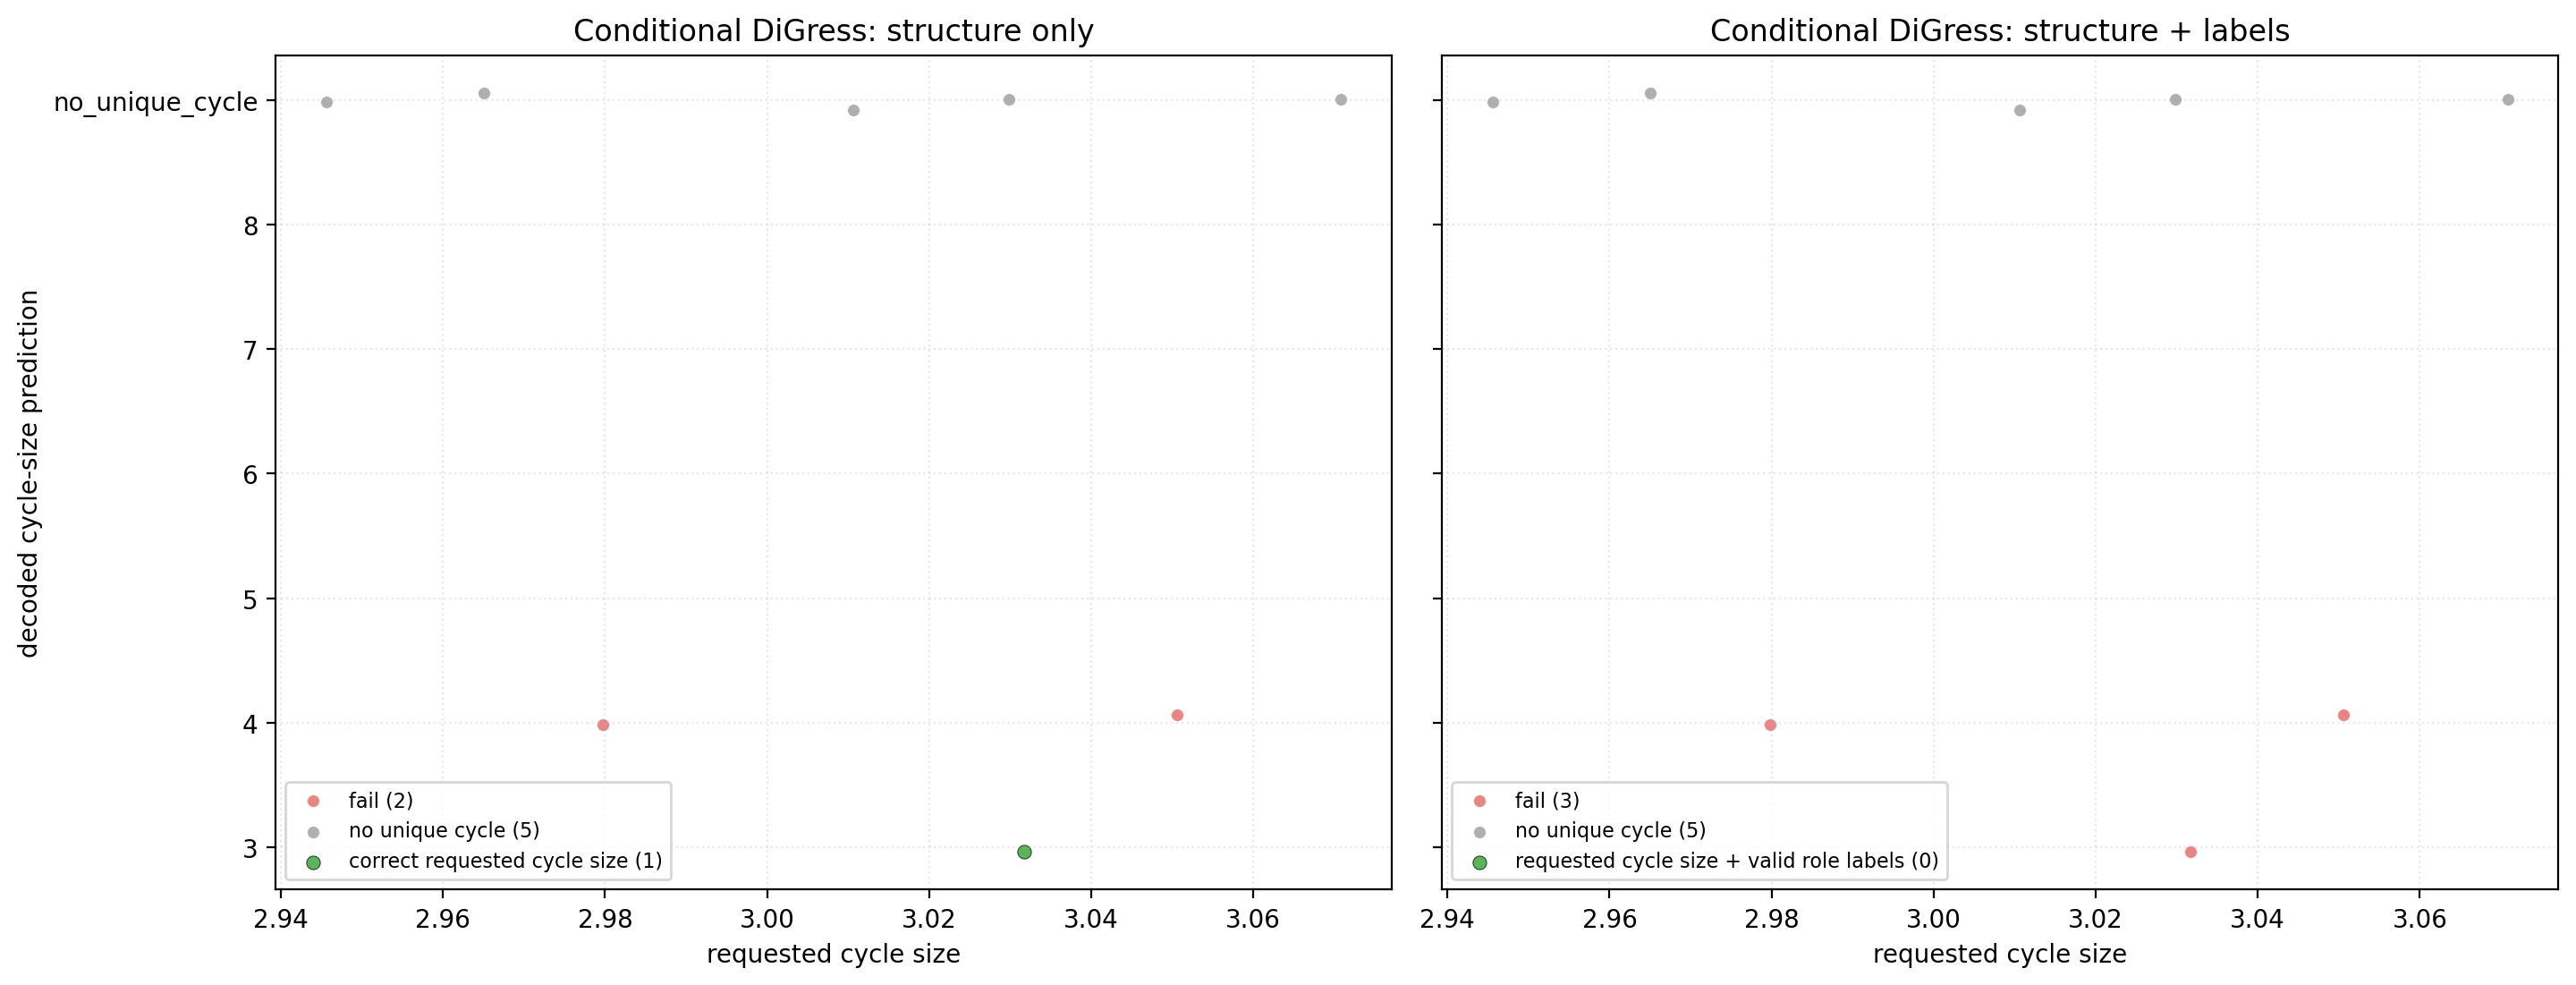

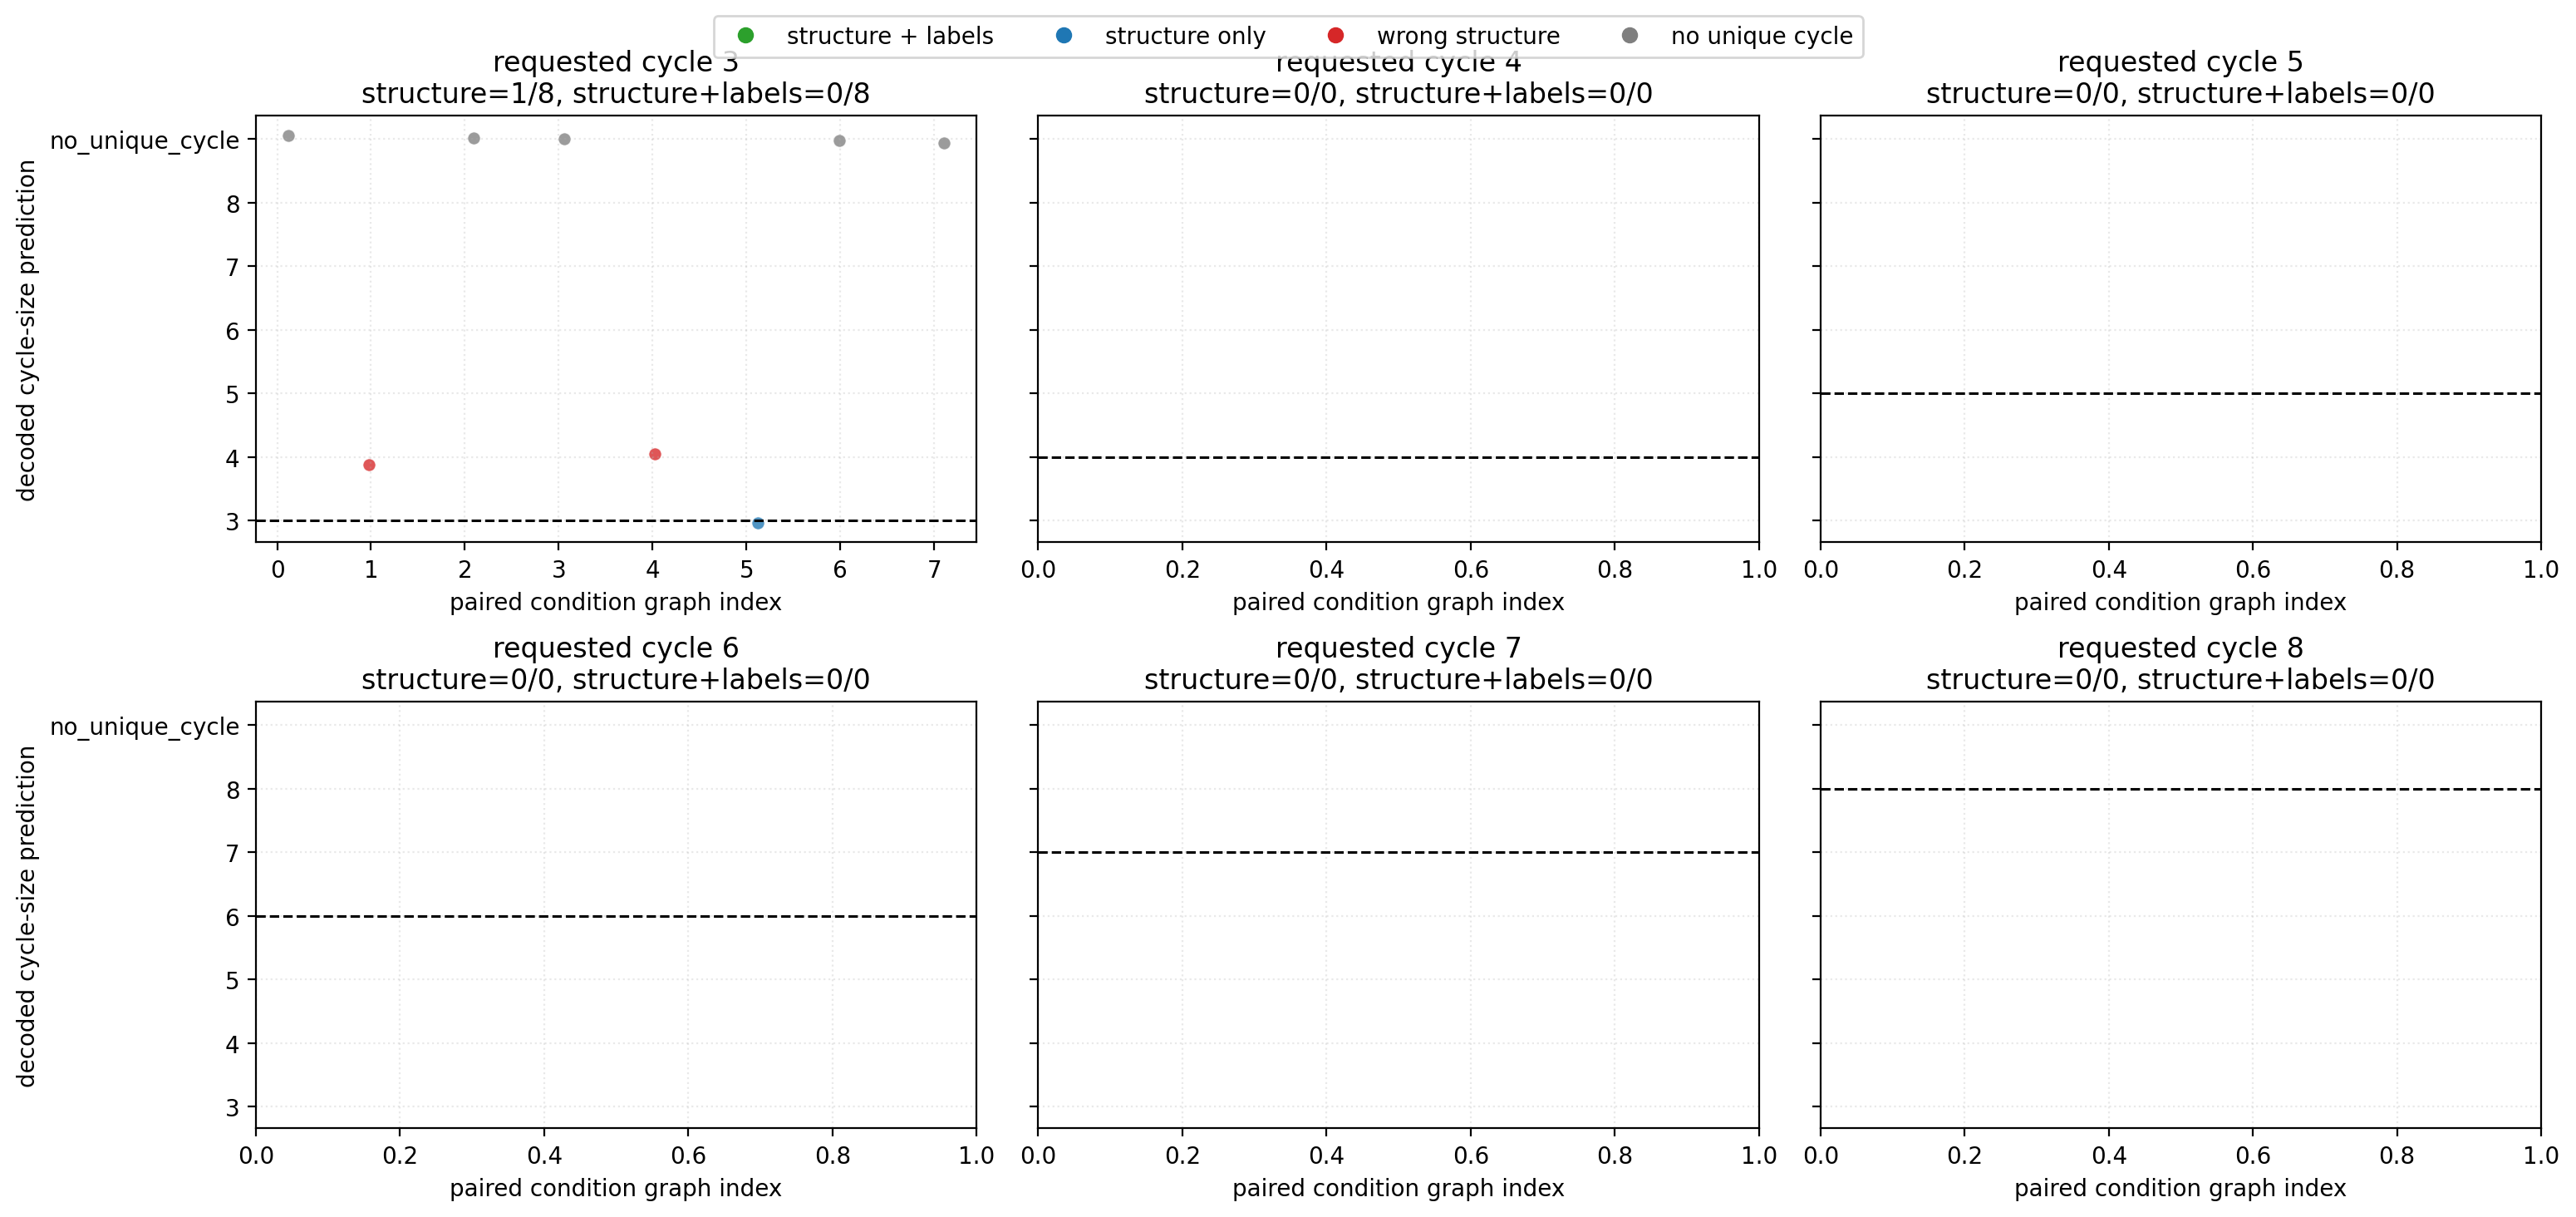

true conditioning/test graphs: cycle_3


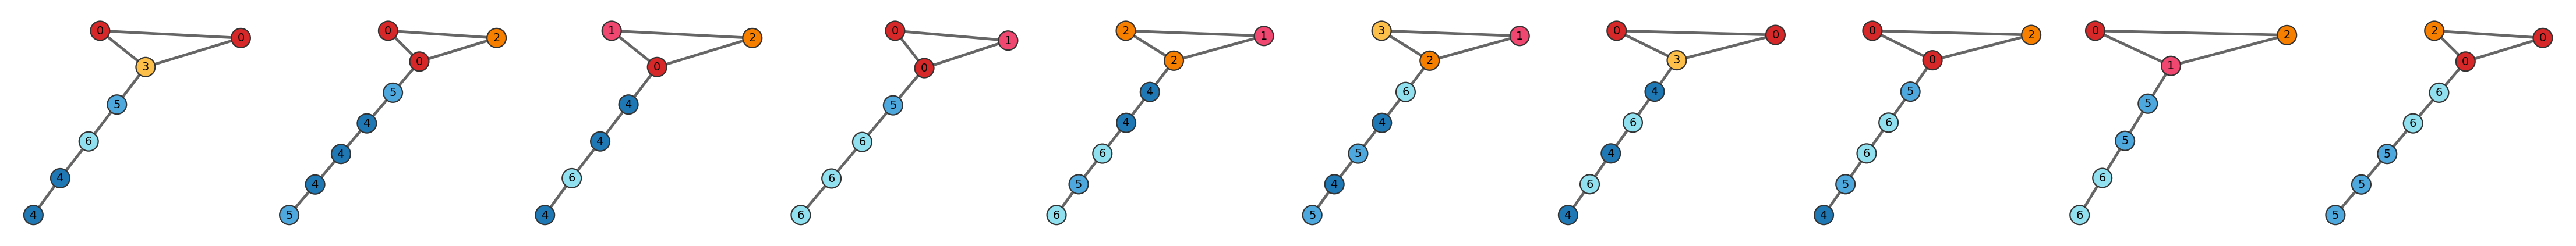

Conditional DiGress generated graphs: cycle_3


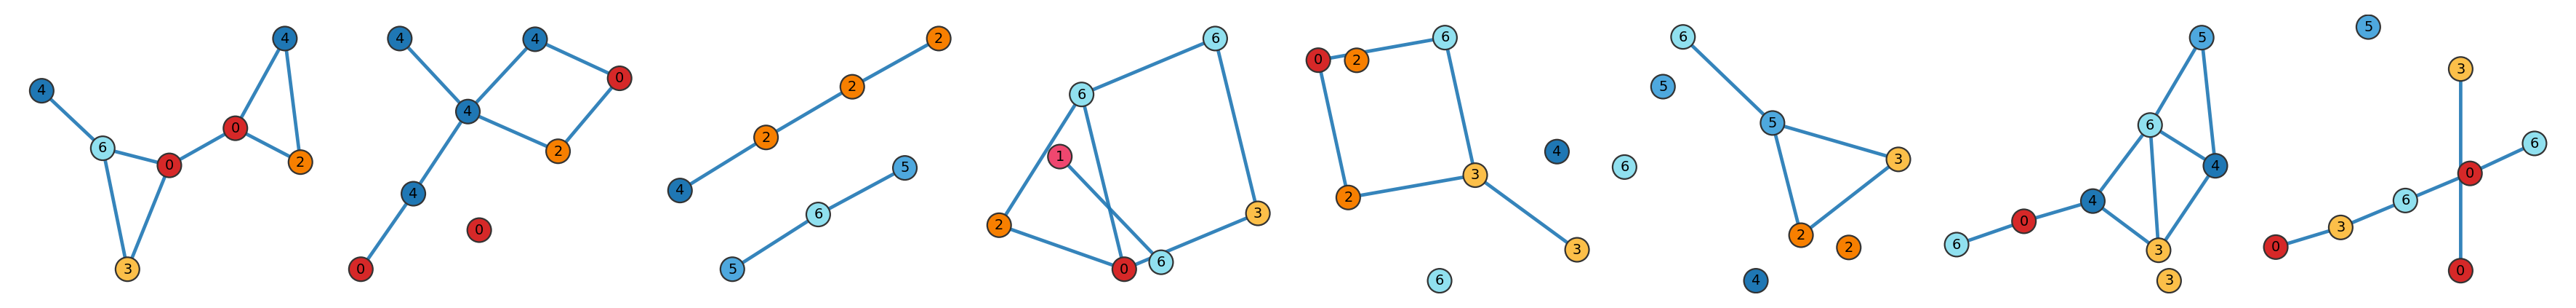

In [44]:
# ===== Load, plot, and evaluate Conditional DiGress samples =====
from collections import Counter
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.display import display

DIGRESS_GENERATED_PATH = Path("DiGress/data/cycle_condition_generated.pt")
DIGRESS_PLOT_PER_CATEGORY = None  # None plots all decoded graphs per category, e.g. 100 for full decode.

if not DIGRESS_GENERATED_PATH.exists():
    print(f"Conditional DiGress output not found: {DIGRESS_GENERATED_PATH.resolve()}")
    print("Train DiGress and run src/sample_cycle_condition.py first.")
else:
    digress_payload = torch.load(DIGRESS_GENERATED_PATH, map_location="cpu")
    digress_samples = list(digress_payload["samples"])
    digress_targets = list(digress_payload.get("targets", []))

    # DiGress predicts node-class indices. Map them back to the original
    # NetworkX node ``label`` values stored by the export cell.
    import ast
    train_export_path = Path("DiGress/data/cycle_condition_graphs.pt")
    node_class_to_label = None
    if train_export_path.exists():
        train_export_payload = torch.load(train_export_path, map_location="cpu")
        raw_label_values = train_export_payload.get("metadata", {}).get("node_label_values")
        if raw_label_values is not None:
            node_class_to_label = []
            for value in raw_label_values:
                if isinstance(value, str):
                    try:
                        value = ast.literal_eval(value)
                    except Exception:
                        pass
                node_class_to_label.append(value)

    def _decode_node_label(class_id):
        class_id = int(class_id)
        if node_class_to_label is None or class_id >= len(node_class_to_label):
            return class_id
        value = node_class_to_label[class_id]
        try:
            numeric = float(value)
            if np.isfinite(numeric) and abs(numeric - round(numeric)) < 1e-9:
                return int(round(numeric))
        except Exception:
            pass
        return value
    if not digress_targets:
        # Older output payloads did not store targets. Fall back to decode input file.
        decode_input_path = Path("DiGress/data/cycle_condition_decode_inputs.pt")
        if decode_input_path.exists():
            decode_payload = torch.load(decode_input_path, map_location="cpu")
            digress_targets = list(decode_payload.get("targets", []))
    if not digress_targets:
        digress_targets = [None] * len(digress_samples)

    def _digress_sample_to_nx(sample):
        atom_types, edge_types = sample
        atom_types = torch.as_tensor(atom_types).cpu()
        edge_types = torch.as_tensor(edge_types).cpu()

        graph = nx.Graph()
        n = int(atom_types.shape[0])
        for node in range(n):
            raw_label = atom_types[node]
            if raw_label.ndim > 0:
                label_class = int(torch.argmax(raw_label).item())
            else:
                label_class = int(raw_label.item())
            label = _decode_node_label(label_class)
            graph.add_node(
                node,
                label=label,
                display_label=label,
                digress_node_class=label_class,
            )

        for i in range(n):
            for j in range(i + 1, n):
                raw_edge = edge_types[i, j]
                if raw_edge.ndim > 0:
                    edge_label = int(torch.argmax(raw_edge).item())
                else:
                    edge_label = int(raw_edge.item())
                if edge_label > 0:
                    graph.add_edge(i, j, label=edge_label, display_label=edge_label)
        return graph

    digress_generated_graphs = [_digress_sample_to_nx(sample) for sample in digress_samples]
    if node_class_to_label is not None:
        print("DiGress node class -> label map:", dict(enumerate(node_class_to_label)))

    if "EVAL_CYCLE_SIZES" not in globals():
        EVAL_CYCLE_SIZES = tuple(int(size) for size in globals().get("CYCLE_SIZES", (3, 4, 5, 6, 7, 8)))
    if "EVAL_GRAPHS_PER_CATEGORY" not in globals():
        EVAL_GRAPHS_PER_CATEGORY = int(globals().get("TEST_GRAPHS_PER_CATEGORY", 100))
    if "EVAL_CYCLE_BUCKETS" not in globals():
        EVAL_CYCLE_BUCKETS = tuple(str(size) for size in EVAL_CYCLE_SIZES) + ("other",)
    if "EVAL_CYCLE_LABELS" not in globals():
        EVAL_CYCLE_LABELS = set(MOTIF_LABELS["target"]) if "MOTIF_LABELS" in globals() else set()
    if "EVAL_LEG_LABELS" not in globals():
        EVAL_LEG_LABELS = set(MOTIF_LABELS["connector"]) if "MOTIF_LABELS" in globals() else set()

    def _digress_unique_cycle_nodes(graph):
        if not isinstance(graph, nx.Graph) or graph.is_directed():
            return None
        try:
            cycles = nx.cycle_basis(graph)
        except (nx.NetworkXError, nx.NetworkXNotImplemented):
            return None
        if len(cycles) != 1:
            return None
        return set(cycles[0])

    def _digress_single_cycle_nodes(graph, cycle_size):
        cycle_nodes = _digress_unique_cycle_nodes(graph)
        if cycle_nodes is None or len(cycle_nodes) != int(cycle_size):
            return None
        return cycle_nodes

    def _digress_cycle_labels_are_valid(graph, cycle_nodes):
        if cycle_nodes is None or not EVAL_CYCLE_LABELS or not EVAL_LEG_LABELS:
            return False
        for node, data in graph.nodes(data=True):
            try:
                label = int(data.get("label"))
            except (TypeError, ValueError):
                return False
            expected_labels = EVAL_CYCLE_LABELS if node in cycle_nodes else EVAL_LEG_LABELS
            if label not in expected_labels:
                return False
        return True

    def _digress_cycle_size_bucket(graph):
        cycle_nodes = _digress_unique_cycle_nodes(graph)
        if cycle_nodes is None:
            return "no_unique_cycle"
        cycle_size = len(cycle_nodes)
        if cycle_size in EVAL_CYCLE_SIZES:
            return str(cycle_size)
        return "other"

    def _digress_metric_row(method_name, category, cycle_size, decoded):
        cycle_matches = [
            _digress_single_cycle_nodes(graph, cycle_size) is not None
            for graph in decoded
        ]
        labeled_cycle_matches = [
            _digress_cycle_labels_are_valid(
                graph,
                _digress_single_cycle_nodes(graph, cycle_size),
            )
            for graph in decoded
        ]
        cycle_size_counts = Counter(_digress_cycle_size_bucket(graph) for graph in decoded)
        n_graphs = len(decoded)
        row = {
            "method": method_name,
            "category": category,
            "requested_cycle_size": int(cycle_size),
            "n": n_graphs,
            "exactly_one_requested_cycle": int(sum(cycle_matches)),
            "exactly_one_requested_cycle_with_valid_labels": int(sum(labeled_cycle_matches)),
            "cycle_rate": float(np.mean(cycle_matches)) if n_graphs else np.nan,
            "cycle_with_valid_labels_rate": float(np.mean(labeled_cycle_matches)) if n_graphs else np.nan,
        }
        for bucket in EVAL_CYCLE_BUCKETS:
            row[f"one_cycle_size_{bucket}"] = int(cycle_size_counts.get(bucket, 0))
        row["one_cycle_size_no_unique_cycle"] = int(cycle_size_counts.get("no_unique_cycle", 0))
        return row

    digress_cycle_category_decoded = {}
    for cycle_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{int(cycle_size)}"
        graphs = [
            graph
            for graph, target in zip(digress_generated_graphs, digress_targets)
            if target == category
        ]
        digress_cycle_category_decoded[category] = graphs

    digress_rows = []
    for cycle_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{int(cycle_size)}"
        decoded = digress_cycle_category_decoded.get(category, [])
        if decoded:
            digress_rows.append(
                _digress_metric_row(
                    "Conditional DiGress",
                    category,
                    cycle_size,
                    decoded,
                )
            )

    digress_cycle_evaluation_results = pd.DataFrame(digress_rows)
    print("Conditional DiGress per-category results")
    display(digress_cycle_evaluation_results)

    # Confusion matrix: requested condition class vs decoded cycle-size bucket.
    digress_point_rows = []
    for requested_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{int(requested_size)}"
        decoded = digress_cycle_category_decoded.get(category, [])
        for pair_index, graph in enumerate(decoded):
            decoded_bucket = _digress_cycle_size_bucket(graph)
            cycle_nodes = _digress_unique_cycle_nodes(graph)
            labels_valid = _digress_cycle_labels_are_valid(graph, cycle_nodes)
            structure_match = decoded_bucket == str(int(requested_size))
            structure_and_labels = bool(structure_match and labels_valid)
            if decoded_bucket == "no_unique_cycle":
                status = "no unique cycle"
            elif structure_and_labels:
                status = "structure + labels"
            elif structure_match:
                status = "structure only"
            else:
                status = "wrong structure"

            digress_point_rows.append(
                {
                    "requested_cycle_size": int(requested_size),
                    "pair_index": int(pair_index),
                    "decoded_cycle_bucket": decoded_bucket,
                    "structure_match": bool(structure_match),
                    "role_labels_valid": bool(labels_valid),
                    "structure_and_label_match": structure_and_labels,
                    "no_unique_cycle": decoded_bucket == "no_unique_cycle",
                    "status": status,
                }
            )

    digress_cycle_datapoint_scatter = pd.DataFrame(digress_point_rows)
    if digress_cycle_datapoint_scatter.empty:
        print("No Conditional DiGress decoded rows to plot.")
    else:
        print("Conditional DiGress requested-vs-decoded rows")
        display(digress_cycle_datapoint_scatter.head())

        digress_confusion = pd.crosstab(
            digress_cycle_datapoint_scatter["requested_cycle_size"],
            digress_cycle_datapoint_scatter["decoded_cycle_bucket"],
            rownames=["requested_cycle_size"],
            colnames=["decoded_cycle_bucket"],
            dropna=False,
        )
        print("Conditional DiGress confusion matrix: requested cycle size vs decoded cycle bucket")
        display(digress_confusion)

        import matplotlib.pyplot as plt
        bucket_order = [str(size) for size in EVAL_CYCLE_SIZES]
        for bucket in ("other", "no_unique_cycle"):
            if bucket in set(digress_cycle_datapoint_scatter["decoded_cycle_bucket"]):
                bucket_order.append(bucket)
        y_positions = {bucket: idx for idx, bucket in enumerate(bucket_order)}

        rng = np.random.default_rng(123)
        plot_df = digress_cycle_datapoint_scatter.copy()
        plot_df["decoded_y"] = plot_df["decoded_cycle_bucket"].map(y_positions)
        plot_df["x_jitter"] = rng.normal(0.0, 0.055, size=len(plot_df))
        plot_df["y_jitter"] = rng.normal(0.0, 0.055, size=len(plot_df))

        fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), sharex=True, sharey=True)
        plot_specs = [
            (axes[0], "structure_match", "Conditional DiGress: structure only", "correct requested cycle size"),
            (axes[1], "structure_and_label_match", "Conditional DiGress: structure + labels", "requested cycle size + valid role labels"),
        ]
        for ax, flag_column, title, success_label in plot_specs:
            success = plot_df[plot_df[flag_column]]
            no_unique = plot_df[(~plot_df[flag_column]) & plot_df["no_unique_cycle"]]
            failure = plot_df[(~plot_df[flag_column]) & (~plot_df["no_unique_cycle"])]

            ax.scatter(
                failure["requested_cycle_size"] + failure["x_jitter"],
                failure["decoded_y"] + failure["y_jitter"],
                s=24,
                alpha=0.56,
                color="#d62728",
                edgecolors="white",
                linewidths=0.25,
                label=f"fail ({len(failure)})",
            )
            ax.scatter(
                no_unique["requested_cycle_size"] + no_unique["x_jitter"],
                no_unique["decoded_y"] + no_unique["y_jitter"],
                s=24,
                alpha=0.62,
                color="#7f7f7f",
                edgecolors="white",
                linewidths=0.25,
                label=f"no unique cycle ({len(no_unique)})",
            )
            ax.scatter(
                success["requested_cycle_size"] + success["x_jitter"],
                success["decoded_y"] + success["y_jitter"],
                s=30,
                alpha=0.78,
                color="#2ca02c",
                edgecolors="black",
                linewidths=0.35,
                label=f"{success_label} ({len(success)})",
            )
            ax.set_title(title)
            ax.set_xlabel("requested cycle size")
            ax.grid(True, linestyle=":", alpha=0.3)
            ax.legend(loc="best", fontsize=8)

        axes[0].set_yticks(range(len(bucket_order)))
        axes[0].set_yticklabels(bucket_order)
        axes[0].set_ylabel("decoded cycle-size prediction")
        plt.tight_layout()
        plt.show()

        status_order = [
            "structure + labels",
            "structure only",
            "wrong structure",
            "no unique cycle",
        ]
        status_colors = {
            "structure + labels": "#2ca02c",
            "structure only": "#1f77b4",
            "wrong structure": "#d62728",
            "no unique cycle": "#7f7f7f",
        }

        import math
        n_cols = min(3, len(EVAL_CYCLE_SIZES))
        n_rows = int(math.ceil(len(EVAL_CYCLE_SIZES) / n_cols))
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.2 * n_cols, 3.6 * n_rows),
            sharey=True,
            squeeze=False,
        )
        for ax, requested_size in zip(axes.ravel(), EVAL_CYCLE_SIZES):
            subset_requested = plot_df[plot_df["requested_cycle_size"] == int(requested_size)]
            for status in status_order:
                subset = subset_requested[subset_requested["status"] == status]
                if subset.empty:
                    continue
                ax.scatter(
                    subset["pair_index"] + rng.normal(0.0, 0.08, size=len(subset)),
                    subset["decoded_y"] + rng.normal(0.0, 0.055, size=len(subset)),
                    s=30,
                    alpha=0.78,
                    color=status_colors[status],
                    edgecolors="white",
                    linewidths=0.35,
                    label=f"{status} ({len(subset)})",
                )
            ax.axhline(
                y_positions[str(requested_size)],
                linestyle="--",
                color="black",
                linewidth=1.1,
            )
            n_structure = int(subset_requested["structure_match"].sum())
            n_both = int(subset_requested["structure_and_label_match"].sum())
            ax.set_title(
                f"requested cycle {requested_size}\n"
                f"structure={n_structure}/{len(subset_requested)}, structure+labels={n_both}/{len(subset_requested)}"
            )
            ax.set_xlabel("paired condition graph index")
            ax.grid(True, linestyle=":", alpha=0.28)

        for ax in axes[:, 0]:
            ax.set_yticks(range(len(bucket_order)))
            ax.set_yticklabels(bucket_order)
            ax.set_ylabel("decoded cycle-size prediction")
        for ax in axes.ravel()[len(EVAL_CYCLE_SIZES):]:
            ax.axis("off")
        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="", color=status_colors[status], label=status)
            for status in status_order
        ]
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02))
        plt.tight_layout()
        plt.show()

    # Plot the same way as the other notebook graph displays: grouped by requested class.
    for cycle_size in EVAL_CYCLE_SIZES:
        category = f"cycle_{int(cycle_size)}"
        all_generated_for_category = digress_cycle_category_decoded.get(category, [])
        if DIGRESS_PLOT_PER_CATEGORY is None:
            generated_subset = list(all_generated_for_category)
        else:
            generated_subset = list(all_generated_for_category)[:int(DIGRESS_PLOT_PER_CATEGORY)]
        if not generated_subset:
            continue

        plot_columns = int(globals().get("EVAL_PLOT_COLUMNS", 10))
        true_subset = []
        if "test_graphs" in globals() and "test_targets" in globals():
            true_candidates = [
                graph
                for graph, target in zip(test_graphs, test_targets)
                if target == category
            ]
            true_subset = true_candidates[:len(generated_subset)]

        if true_subset:
            print(f"true conditioning/test graphs: {category} ({len(true_subset)})")
            plot_networkx_graphs(
                true_subset,
                n_cols=plot_columns,
                figsize_per_graph=(2.0, 1.8),
                node_label_attr="label",
                edge_label_attr="label",
                node_size=100,
                edge_width=1.3,
                font_size=5,
                layout="kamada_kawai",
            )

        print(f"Conditional DiGress generated graphs: {category} ({len(generated_subset)})")
        plot_networkx_graphs(
            generated_subset,
            n_cols=plot_columns,
            figsize_per_graph=(2.0, 1.8),
            node_label_attr="label",
            edge_label_attr="label",
            node_size=100,
            edge_width=1.3,
            font_size=5,
            layout="kamada_kawai",
        )

    if "all_cycle_evaluation_results" in globals():
        all_cycle_evaluation_results = pd.concat(
            [all_cycle_evaluation_results, digress_cycle_evaluation_results],
            ignore_index=True,
        )
    elif "cycle_evaluation_results" in globals():
        all_cycle_evaluation_results = pd.concat(
            [cycle_evaluation_results, digress_cycle_evaluation_results],
            ignore_index=True,
        )
    else:
        all_cycle_evaluation_results = digress_cycle_evaluation_results.copy()






In [45]:
# ===== Final Conditional DiGress metrics summary =====
from IPython.display import display

candidate_result_names = [
    "all_cycle_evaluation_results",
    "digress_cycle_evaluation_results",
]
result_name = next(
    (name for name in candidate_result_names if name in globals()),
    None,
)

if result_name is None:
    print("No Conditional DiGress metrics table exists in this notebook kernel yet.")
    print(
        "Run the cell titled 'Conditional DiGress Results - Load, Plot, and Evaluate' "
        "after decoding graphs with src/sample_cycle_condition.py."
    )
    print(
        "That DiGress cell requires the generated file: "
        "DiGress/data/cycle_condition_generated.pt"
    )
else:
    all_experiment_results = globals()[result_name].copy()
    all_experiment_summary = (
        all_experiment_results.groupby("method", as_index=False)
        .agg(
            n=("n", "sum"),
            exactly_one_requested_cycle=(
                "exactly_one_requested_cycle",
                "sum",
            ),
            exactly_one_requested_cycle_with_valid_labels=(
                "exactly_one_requested_cycle_with_valid_labels",
                "sum",
            ),
        )
    )
    all_experiment_summary["cycle_rate"] = (
        all_experiment_summary["exactly_one_requested_cycle"]
        / all_experiment_summary["n"]
    )
    all_experiment_summary["cycle_with_valid_labels_rate"] = (
        all_experiment_summary[
            "exactly_one_requested_cycle_with_valid_labels"
        ]
        / all_experiment_summary["n"]
    )

    print(f"Using results table: {result_name}")
    print("Per-category Conditional DiGress results")
    display(all_experiment_results)
    print("Overall Conditional DiGress summary")
    display(all_experiment_summary)



Using results table: all_cycle_evaluation_results
Per-category Conditional DiGress results


,method,category,requested_cycle_size,n,exactly_one_requested_cycle,exactly_one_requested_cycle_with_valid_labels,cycle_rate,cycle_with_valid_labels_rate,one_cycle_size_3,one_cycle_size_4,one_cycle_size_5,one_cycle_size_6,one_cycle_size_7,one_cycle_size_8,one_cycle_size_other,one_cycle_size_no_unique_cycle
0,Conditional DiGress,cycle_3,3,8,1,0,0.125,0.0,1,2,0,0,0,0,0,5
1,Conditional DiGress,cycle_3,3,8,1,0,0.125,0.0,1,2,0,0,0,0,0,5


Overall Conditional DiGress summary


,method,n,exactly_one_requested_cycle,exactly_one_requested_cycle_with_valid_labels,cycle_rate,cycle_with_valid_labels_rate
0,Conditional DiGress,16,2,0,0.125,0.0
